# MC Correction Fit  —  hMcCorrectionP / hMcCorrectionM

Single global WLS in log space with z–Q² and z–xB interaction terms:

$$\ln C = \underbrace{P(\ln x_B,\, \ln Q^2)}_{\text{kinematic}} + \sum_{k=1}^{d_R} r_k(\ln x_B,\, \ln Q^2)\; z^k$$

where the z-coefficients carry separate Q² and xB modulations:

$$r_k(\ln x_B, \ln Q^2) = \underbrace{\sum_{m=0}^{d_{ZQ}} c_{km}^{(Q)}\,(\ln Q^2)^m}_{\text{Q}^2\text{-shape}} + \underbrace{\sum_{n=1}^{d_{ZX}} c_{kn}^{(x)}\,(\ln x_B)^n}_{x_B\text{-shape}}$$

$$P = \sum_{\substack{i,j \ge 0 \\ i+j \le d_P}} p_{ij}\,(\ln x_B)^i\,(\ln Q^2)^j \quad \text{(carries the intercept and pure kinematic dependence)}$$

- $d_{ZQ}=0,\; d_{ZX}=0$: pure factorized model $\ln C = P + R(z)$
- $d_{ZQ}>0$: z-shape varies with $Q^2$
- $d_{ZX}>0$: z-shape varies with $x_B$

Final form: $C = \exp(\ln C)$, guaranteed positive.

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
from itertools import product as iproduct

FILE        = '../data/correctionFiles/corrections_10.2_rga.root'
OUTPUT_FILE =  None#'../data/correctionFiles/corrections_10.2_rga_fit.root'#'../data/correctionFiles/corrections_10.2_1_fit.root'#'../data/correctionFiles/corrections_10.2_fit.root'

FILE_4D  = '../data/correctionFiles/corrections_10.2_pT_no_match.root'#'../data/correctionFiles/corrections_10.6_pT.root'
OUT_4D   = '../data/correctionFiles/corrections_10.2_pT_no_match_fit.root'



In [2]:
DEG_P  = 3   # total degree of 2D polynomial P in (ln xB, ln Q²)
DEG_R  = 3   # degree of z polynomial
DEG_ZQ = 2   # degree of Q² modulation of each z^k coefficient  (0 = none)
DEG_ZX = 2   # degree of xB modulation of each z^k coefficient  (0 = none)
# ── Smoothing ──────────────────────────────────────────────────────────────────
SMOOTH       = False  # set True to enable
SMOOTH_SIGMA = [.25,.25,.25]    # Gaussian σ in bins; scalar or [σ_xB, σ_Q2, σ_z]

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#444444',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        '#dddddd',
    'grid.linewidth':    0.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'font.family':       'sans-serif',
})

# Sample tab20 for up to 20 distinct colours
import matplotlib.cm as mcm
_cmap   = mcm.get_cmap('tab20')
N_COLORS = 20
COLOR_LIST = [_cmap(i / N_COLORS) for i in range(N_COLORS)]

LABEL = {'xB': r'$x_B$', 'Q2': r'$Q^2\;[\mathrm{GeV}^2]$', 'z': r'$z$'}

def panel_label(ax, text):
    """Small text box in the upper-right corner of a panel."""
    ax.text(0.96, 0.96, text,
            transform=ax.transAxes, ha='right', va='top',
            fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25', fc='white',
                      ec='#aaaaaa', alpha=0.85))

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_99346/1997478588.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap   = mcm.get_cmap('tab20')


In [3]:
# ── Load histograms, define model, run fits ───────────────────────────────────

# ── (i,j) pairs for total-degree-d 2D polynomial ─────────────────────────────
def _p_terms(d):
    return [(i, j) for i in range(d + 1) for j in range(d + 1 - i)]

# ── Design-matrix builder ─────────────────────────────────────────────────────
def _build_features(z, ln_x, ln_q, pt, zq_terms, zx_terms):
    """
    z, ln_x, ln_q : 1-D arrays of length N.
    Returns X of shape (N, M).
    z is normalised: t = (z - _Z_MID) / _Z_RNG.
    """
    t = (z - _Z_MID) / _Z_RNG
    cols = []
    for (i, j) in pt:
        cols.append(ln_x**i * ln_q**j)
    for (k, m) in zq_terms:
        cols.append(t**k * ln_q**m)
    for (k, n) in zx_terms:
        cols.append(t**k * ln_x**n)
    return np.column_stack(cols)

# ── Predictor ─────────────────────────────────────────────────────────────────
class Predictor:
    def __init__(self, theta, cov, pt, zq_terms, zx_terms):
        self.theta = theta
        self.cov   = cov
        self._pt   = pt
        self._zq   = zq_terms
        self._zx   = zx_terms

    def _X(self, z, x, q):
        return _build_features(
            np.asarray(z).ravel(),
            np.log(np.asarray(x).ravel()),
            np.log(np.asarray(q).ravel()),
            self._pt, self._zq, self._zx)

    def lnc(self, z, x, q):
        return self._X(z, x, q) @ self.theta

    def __call__(self, z, x, q):
        return np.exp(self.lnc(z, x, q))

    def sigma(self, z, x, q):
        """σ_{ln C} — fractional uncertainty."""
        X   = self._X(z, x, q)
        var = np.einsum('ni,ij,nj->n', X, self.cov, X)
        return np.sqrt(np.maximum(var, 0))

    def sigma_C(self, z, x, q):
        """σ_C = C · σ_{ln C}."""
        return self(z, x, q) * self.sigma(z, x, q)

# ── WLS fit in log space ──────────────────────────────────────────────────────
def fit_factorized(vals, errs,
                   deg_p=None, deg_r=None, deg_zq=None, deg_zx=None):
    if deg_p  is None: deg_p  = DEG_P
    if deg_r  is None: deg_r  = DEG_R
    if deg_zq is None: deg_zq = DEG_ZQ
    if deg_zx is None: deg_zx = DEG_ZX

    pt       = _p_terms(deg_p)
    zq_terms = [(k, m) for k in range(1, deg_r  + 1) for m in range(deg_zq + 1)]
    zx_terms = [(k, n) for k in range(1, deg_r  + 1) for n in range(1, deg_zx + 1)]

    rows_z, rows_x, rows_q, rows_y, rows_w = [], [], [], [], []
    for ix, iq, iz in iproduct(range(n_xB), range(n_Q2), range(n_z)):
        v = vals[ix, iq, iz];  e = errs[ix, iq, iz]
        if not (np.isfinite(v) and np.isfinite(e) and v > 0 and e > 0):
            continue
        rows_z.append(z_centers[iz])
        rows_x.append(xB_centers[ix])
        rows_q.append(Q2_centers[iq])
        rows_y.append(np.log(v))
        rows_w.append((v / e) ** 2)   # 1 / σ²_{ln C}

    z_arr = np.array(rows_z);  x_arr = np.array(rows_x)
    q_arr = np.array(rows_q);  y_arr = np.array(rows_y)
    w_arr = np.array(rows_w)

    X   = _build_features(z_arr, np.log(x_arr), np.log(q_arr),
                          pt, zq_terms, zx_terms)
    XtW   = X.T * w_arr
    A     = XtW @ X
    b     = XtW @ y_arr
    theta = np.linalg.solve(A, b)
    cov   = np.linalg.inv(A)
    n_par = len(theta)

    pred  = Predictor(theta, cov, pt, zq_terms, zx_terms)

    resid = y_arr - X @ theta
    chi2  = float(w_arr @ resid**2)
    ndof  = len(y_arr) - n_par
    chi2_per_ndof = chi2 / ndof if ndof > 0 else float('nan')
    print(f'  deg_p={deg_p} deg_r={deg_r} deg_zq={deg_zq} deg_zx={deg_zx}  '
          f'n_par={n_par}  χ²/ndof={chi2_per_ndof:.3f}  ({len(y_arr)} bins, ndof={ndof})')
    return theta, cov, pred, n_par

# ── Load histograms ───────────────────────────────────────────────────────────
with uproot.open(FILE) as f:
    hP = f['hMcCorrectionP']
    hM = f['hMcCorrectionM']

    #hP = f['hBinMigrationP']
    #hM = f['hBinMigrationM']

xB_edges = hP.axes[0].edges()
Q2_edges = hP.axes[1].edges()
z_edges  = hP.axes[2].edges()

xB_centers = 0.5 * (xB_edges[:-1] + xB_edges[1:])
Q2_centers = 0.5 * (Q2_edges[:-1] + Q2_edges[1:])
z_centers  = 0.5 * (z_edges[:-1]  + z_edges[1:])

n_xB = len(xB_centers)
n_Q2 = len(Q2_centers)
n_z  = len(z_centers)

# z normalisation (must match _tz_str() in the TF3 cell)
_Z_MID = 0.5 * (z_edges[0] + z_edges[-1])
_Z_RNG = 0.5 * (z_edges[-1] - z_edges[0])

vals_P = hP.values().copy()      # shape (n_xB, n_Q2, n_z)
errs_P = np.sqrt(hP.variances())
vals_M = hM.values().copy()
errs_M = np.sqrt(hM.variances())

# Mark empty / invalid bins as NaN
for v, e in [(vals_P, errs_P), (vals_M, errs_M)]:
    bad = ~(np.isfinite(v) & (v > 0) & np.isfinite(e) & (e > 0))
    v[bad] = np.nan;  e[bad] = np.nan

# Optional smoothing
if SMOOTH:
    from scipy.ndimage import gaussian_filter
    sig = SMOOTH_SIGMA if not np.isscalar(SMOOTH_SIGMA) else [SMOOTH_SIGMA]*3
    for v in [vals_P, vals_M]:
        finite = np.isfinite(v)
        tmp = np.where(finite, v, 0.0)
        wgt = gaussian_filter(finite.astype(float), sig)
        v[:] = np.where(finite,
                        gaussian_filter(tmp, sig) / np.where(wgt > 0, wgt, 1),
                        np.nan)

print(f'Loaded: xB={n_xB} bins, Q²={n_Q2} bins, z={n_z} bins')
print(f'z normalisation: mid={_Z_MID:.4f}, rng={_Z_RNG:.4f}')

# ── Plot ranges ───────────────────────────────────────────────────────────────
Y_LIM       = (0.5, 6.0)
Y_LIM_RATIO = (0.5, 2.0)
z_fine      = np.linspace(z_edges[0], z_edges[-1], 300)

# ── Run fits ──────────────────────────────────────────────────────────────────
print('\nFitting π⁺ ...')
c_fac_P, _, pred_fac_P, _ = fit_factorized(vals_P, errs_P)
print('Fitting π⁻ ...')
c_fac_M, _, pred_fac_M, _ = fit_factorized(vals_M, errs_M)

Loaded: xB=14 bins, Q²=12 bins, z=14 bins
z normalisation: mid=0.6500, rng=0.3500

Fitting π⁺ ...
  deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=0.913  (392 bins, ndof=367)
Fitting π⁻ ...
  deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=0.859  (378 bins, ndof=353)


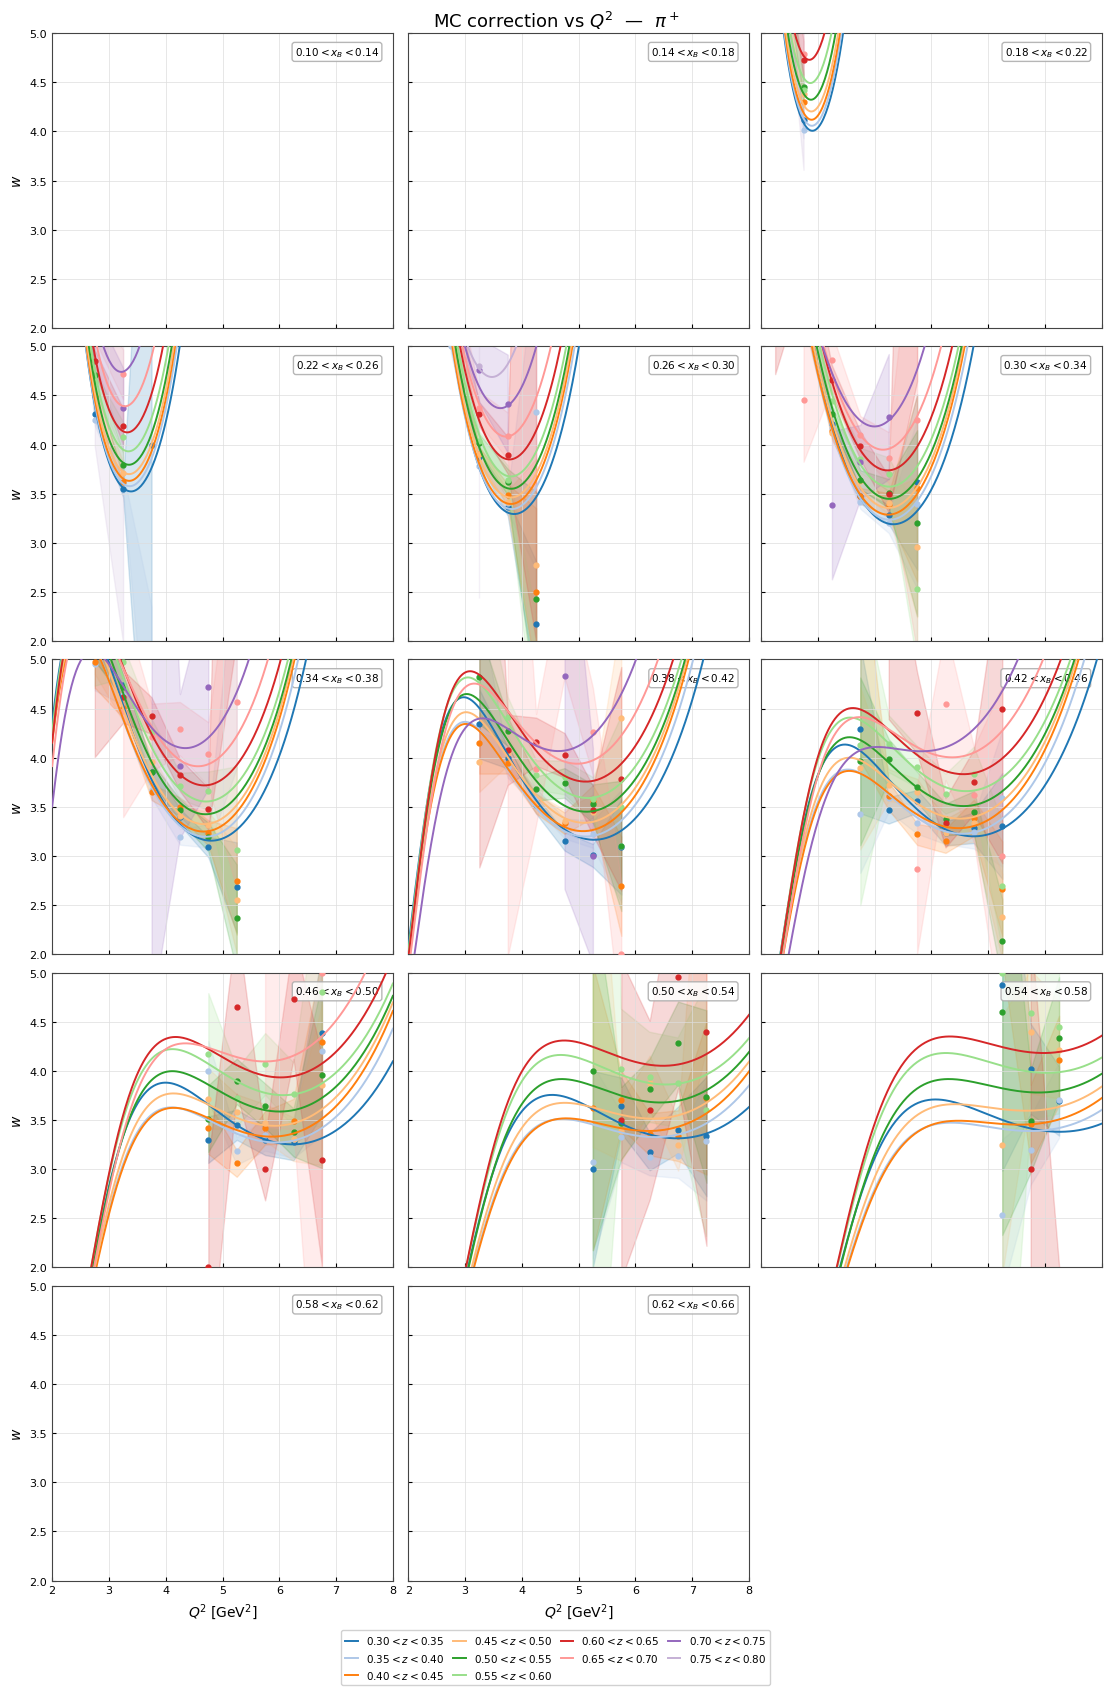

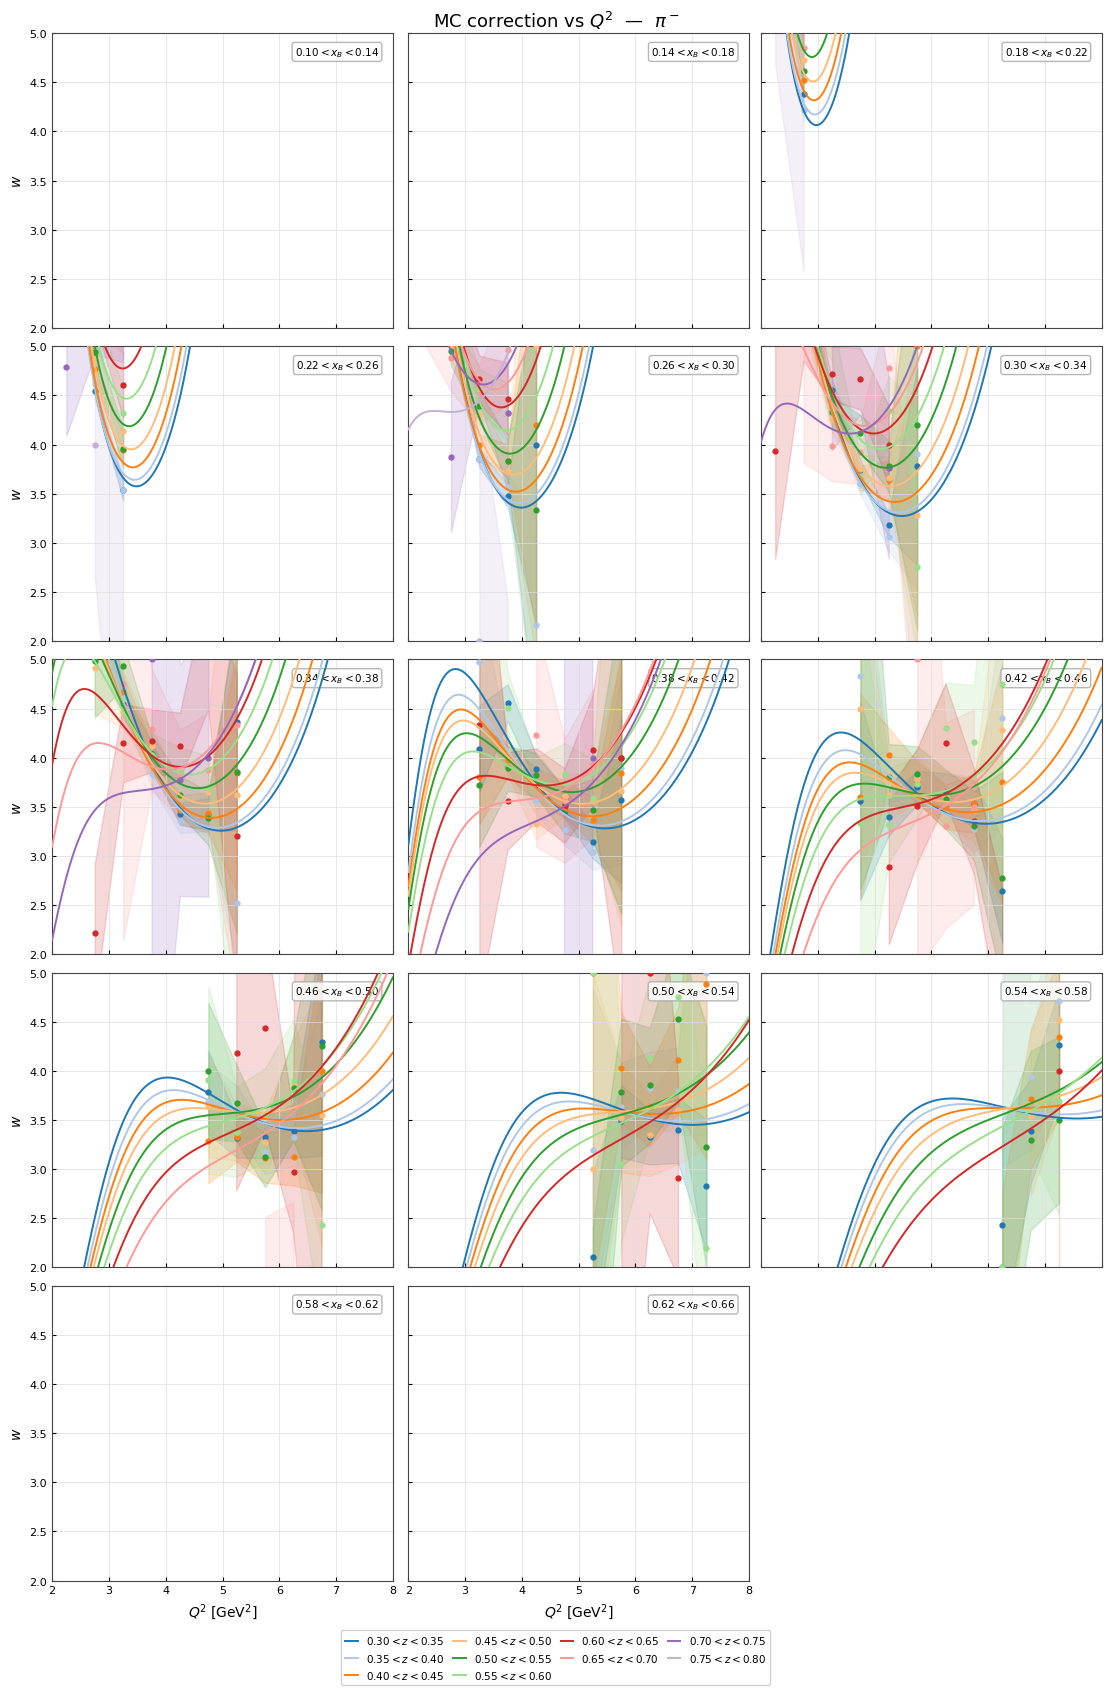

In [4]:
# ── Correction vs Q2  (panels = xB bins, colours = z bins) ───────────────────
q_fine = np.linspace(Q2_edges[0], Q2_edges[-1], 300)

def plot_vs_q(vals, errs, predict, sign_label, y_lim=Y_LIM):
    ncols = 3
    nrows = math.ceil(n_xB / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows),
                             constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(rf'MC correction vs $Q^2$  —  {sign_label}', fontsize=13, y=1.01)
    axs_flat = axs.ravel()

    for ix in range(n_xB):
        ax = axs_flat[ix]
        panel_label(ax, rf'${xB_edges[ix]:.2f} < x_B < {xB_edges[ix+1]:.2f}$')

        for iz in range(n_z):
            v, e = vals[ix, :, iz], errs[ix, :, iz]
            if not np.any(np.isfinite(v)):
                continue
            c = COLOR_LIST[iz]
            label = rf'${z_edges[iz]:.2f} < z < {z_edges[iz+1]:.2f}$'
            ax.fill_between(Q2_centers, v - e, v + e, color=c, alpha=0.18)
            ax.plot(Q2_centers, v, 'o', color=c, ms=3.5, zorder=3)
            z_fix = np.full_like(q_fine, z_centers[iz])
            x_fix = np.full_like(q_fine, xB_centers[ix])
            ax.plot(q_fine, predict(z_fix, x_fix, q_fine),
                    color=c, lw=1.4, label=label, zorder=4)

        ax.axhline(1.0, color='#666666', lw=0.8, ls='--', zorder=1)
        ax.set_xlim(Q2_edges[0], Q2_edges[-1])
        ax.set_ylim([2,5])
        col = ix % ncols
        row = ix // ncols
        if col == 0:
            ax.set_ylabel(r'$w$', fontsize=10)
        if row == nrows - 1:
            ax.set_xlabel(LABEL['Q2'], fontsize=10)

    for ix in range(n_xB, nrows * ncols):
        axs_flat[ix].set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in np.array(axs).ravel():
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=4,
               fontsize=7.5, frameon=True, columnspacing=0.8, handlelength=1.2)
    return fig

plot_vs_q(vals_P, errs_P, pred_fac_P, r'$\pi^+$')
plt.show()
plot_vs_q(vals_M, errs_M, pred_fac_M, r'$\pi^-$')
plt.show()

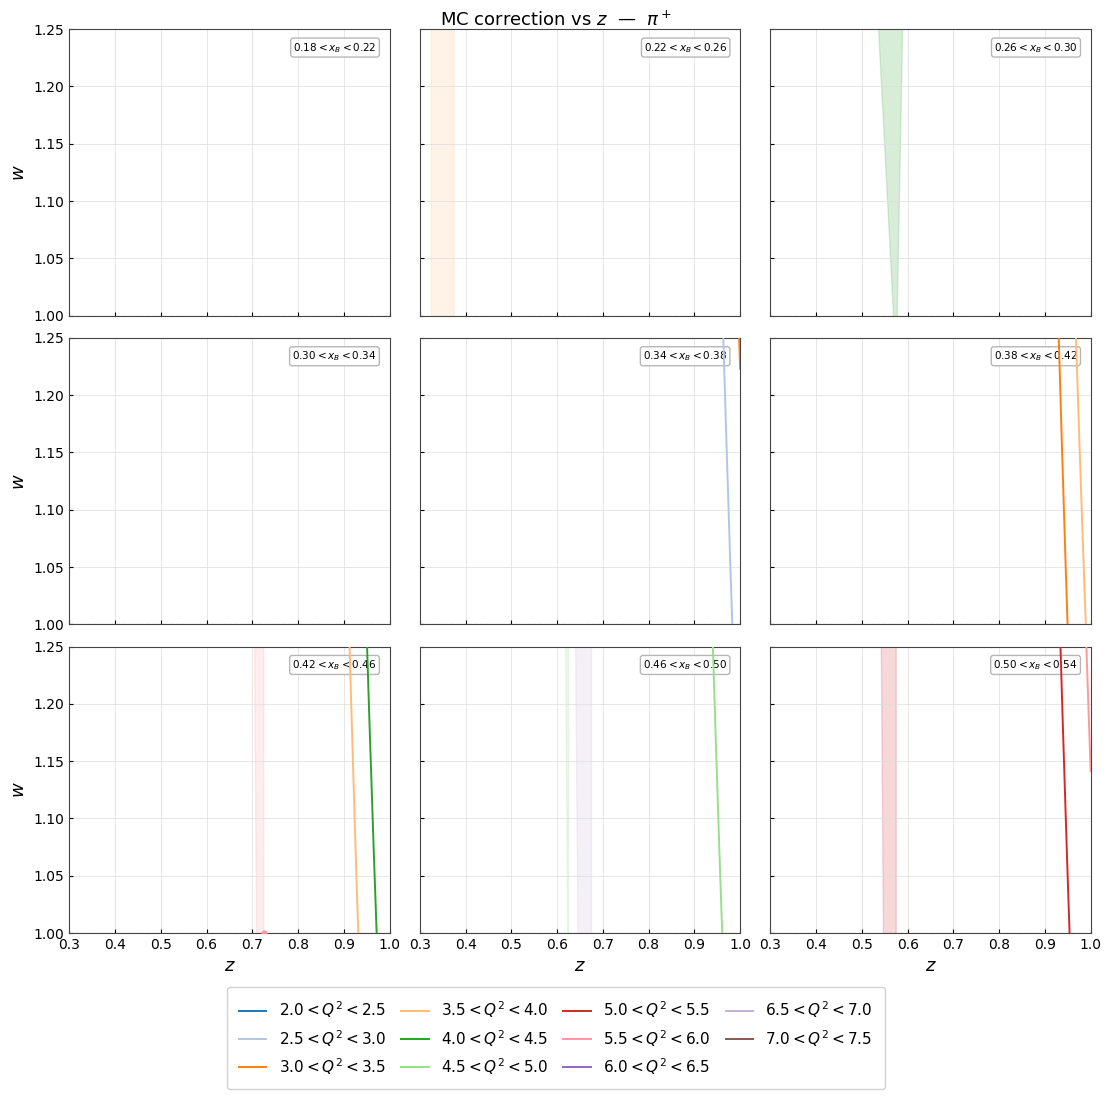

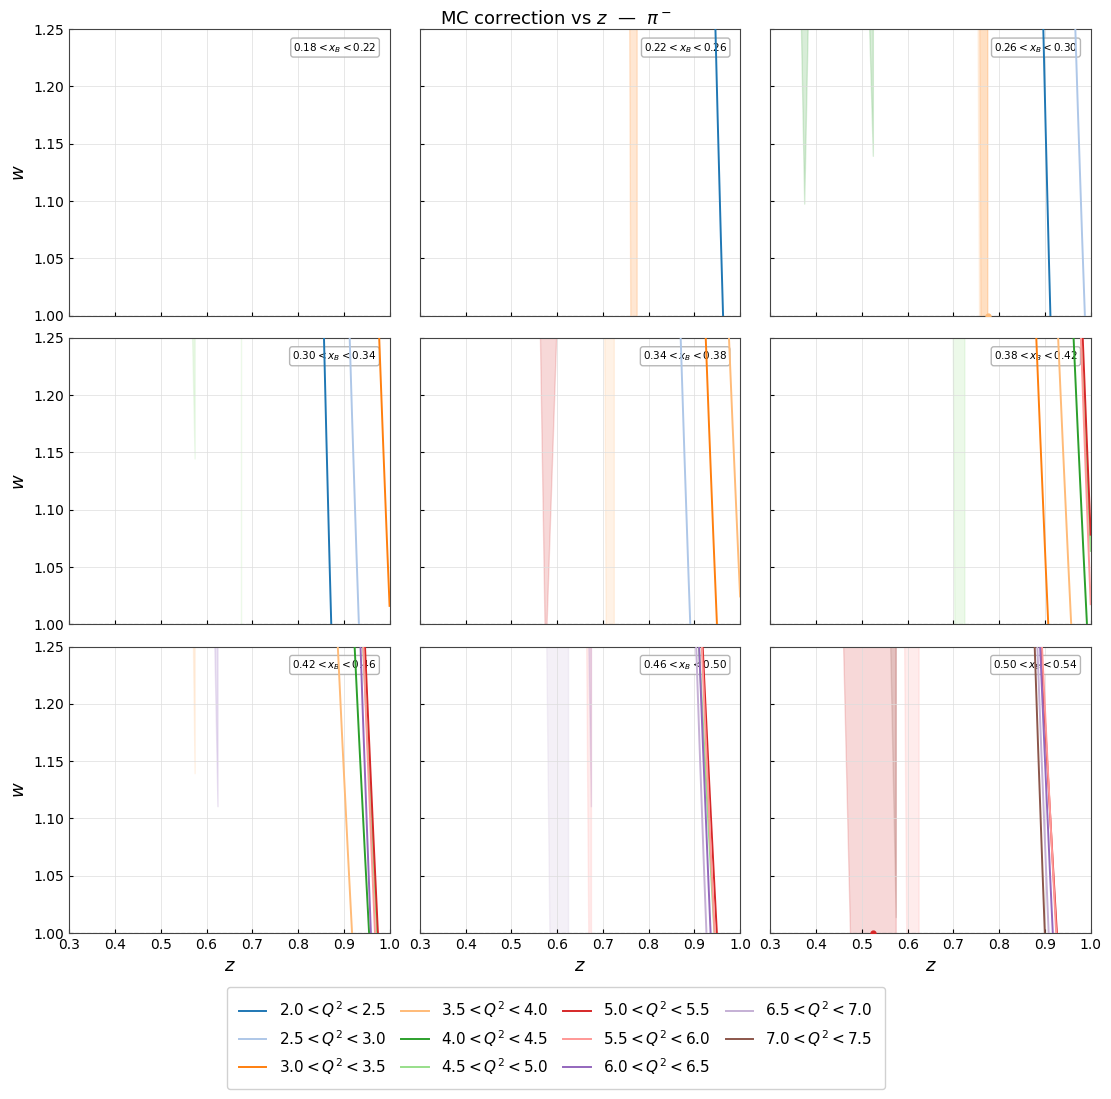

In [5]:
# ── w⁺ and w⁻ vs z  (separate figures, panels = xB bins, colours = Q2 bins) ──
def plot_vs_z(vals, errs, pred, sign_label, y_lim=Y_LIM):
    # Drop xB bins where no Q2 slice has any finite data
    active_ix = [ix for ix in range(n_xB)
                 if any(np.isfinite(vals[ix, iq, :]).any() for iq in range(n_Q2))]
    active_ix = active_ix[1:-1]  # remove first and last (empty boundary bins)
    n_active = len(active_ix)

    ncols = 3
    nrows = math.ceil(n_active / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows),
                             constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(rf'MC correction vs $z$  —  {sign_label}', fontsize=13, y=1.01)
    axs_flat = np.array(axs).ravel()

    for panel, ix in enumerate(active_ix):
        ax = axs_flat[panel]
        panel_label(ax, rf'${xB_edges[ix]:.2f} < x_B < {xB_edges[ix+1]:.2f}$')

        for iq in range(n_Q2):
            c     = COLOR_LIST[iq]
            label = rf'${Q2_edges[iq]:.1f} < Q^2 < {Q2_edges[iq+1]:.1f}$'
            v, e  = vals[ix, iq, :], errs[ix, iq, :]
            mask  = np.isfinite(v) & np.isfinite(e)
            if not mask.any():
                continue
            x_fix = np.full_like(z_fine, xB_centers[ix])
            q_fix = np.full_like(z_fine, Q2_centers[iq])

            ax.fill_between(z_centers, v - e, v + e, color=c, alpha=0.18)
            ax.plot(z_centers[mask], v[mask], 'o', color=c, ms=3.5, zorder=3)
            ax.plot(z_fine, pred(z_fine, x_fix, q_fix),
                    color=c, lw=1.4, label=label, zorder=4)

        ax.axhline(1.0, color='#666666', lw=0.8, ls='--', zorder=1)
        ax.set_xlim(z_edges[0], z_edges[-1])
        ax.set_ylim([1,1.25])#y_lim)#[1,1.25])
        col = panel % ncols
        row = panel // ncols
        if col == 0:
            ax.set_ylabel(r'$w$', fontsize=13)
        if row == nrows - 1:
            ax.set_xlabel(LABEL['z'], fontsize=13)
        ax.tick_params(labelsize=10)

    for panel in range(n_active, nrows * ncols):
        axs_flat[panel].set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in axs_flat[:n_active]:
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=4,
               fontsize=11, frameon=True, columnspacing=1.0,
               handlelength=1.8, borderpad=0.8)
    return fig

plot_vs_z(vals_P, errs_P, pred_fac_P, r'$\pi^+$')
plt.show()
plot_vs_z(vals_M, errs_M, pred_fac_M, r'$\pi^-$')
plt.show()


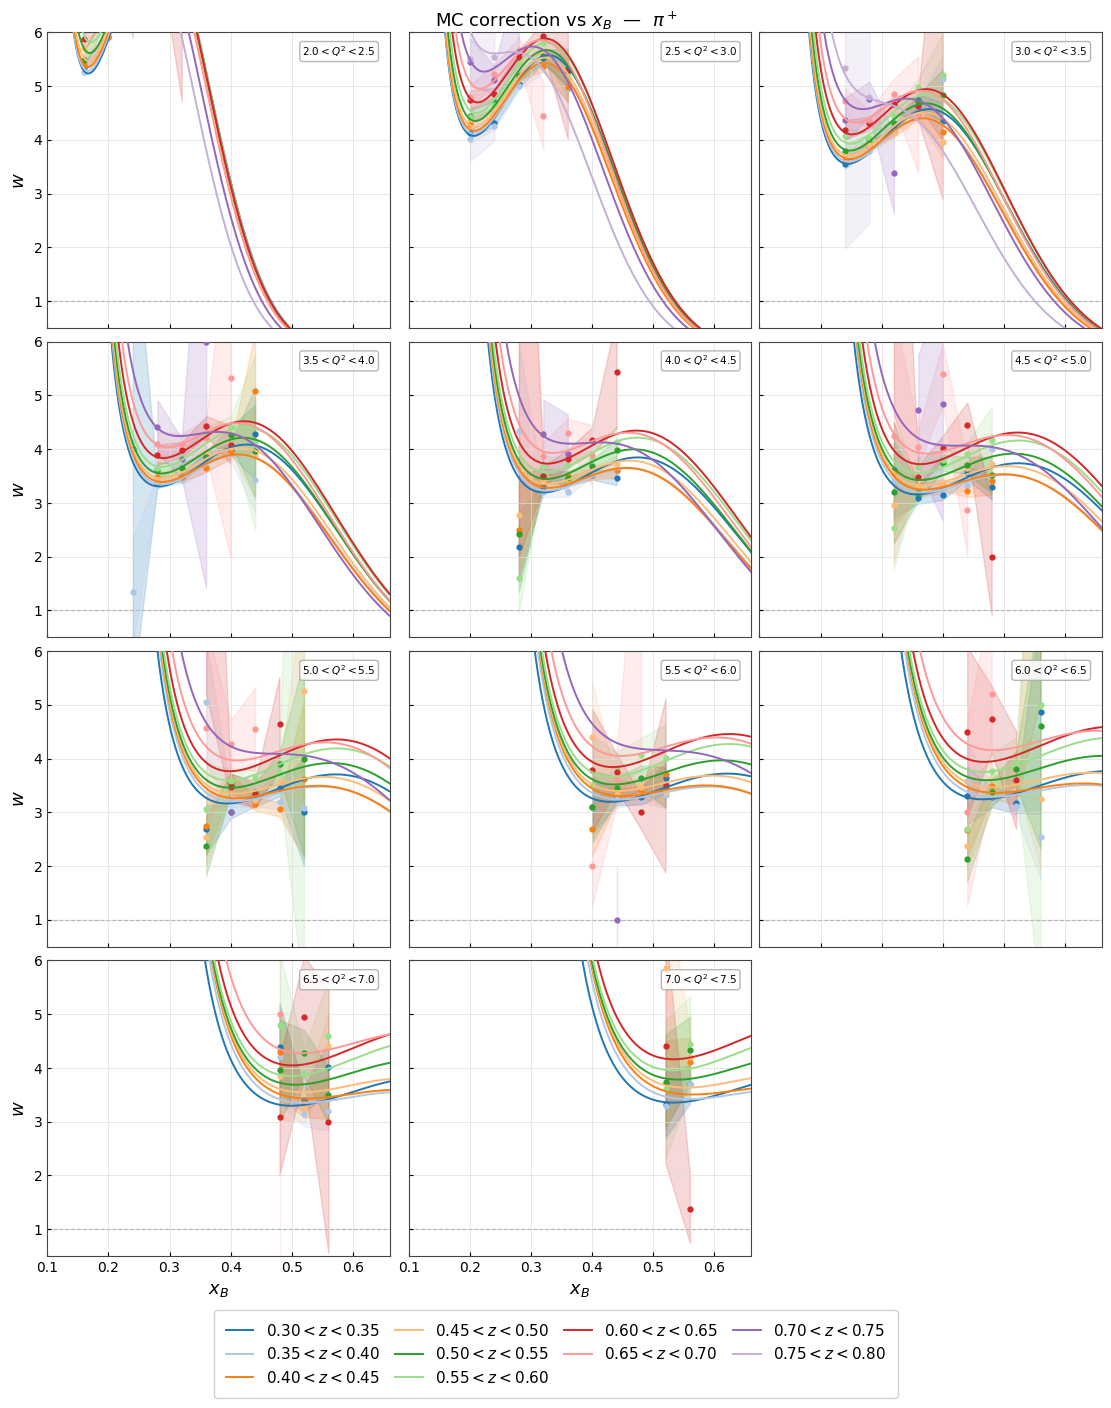

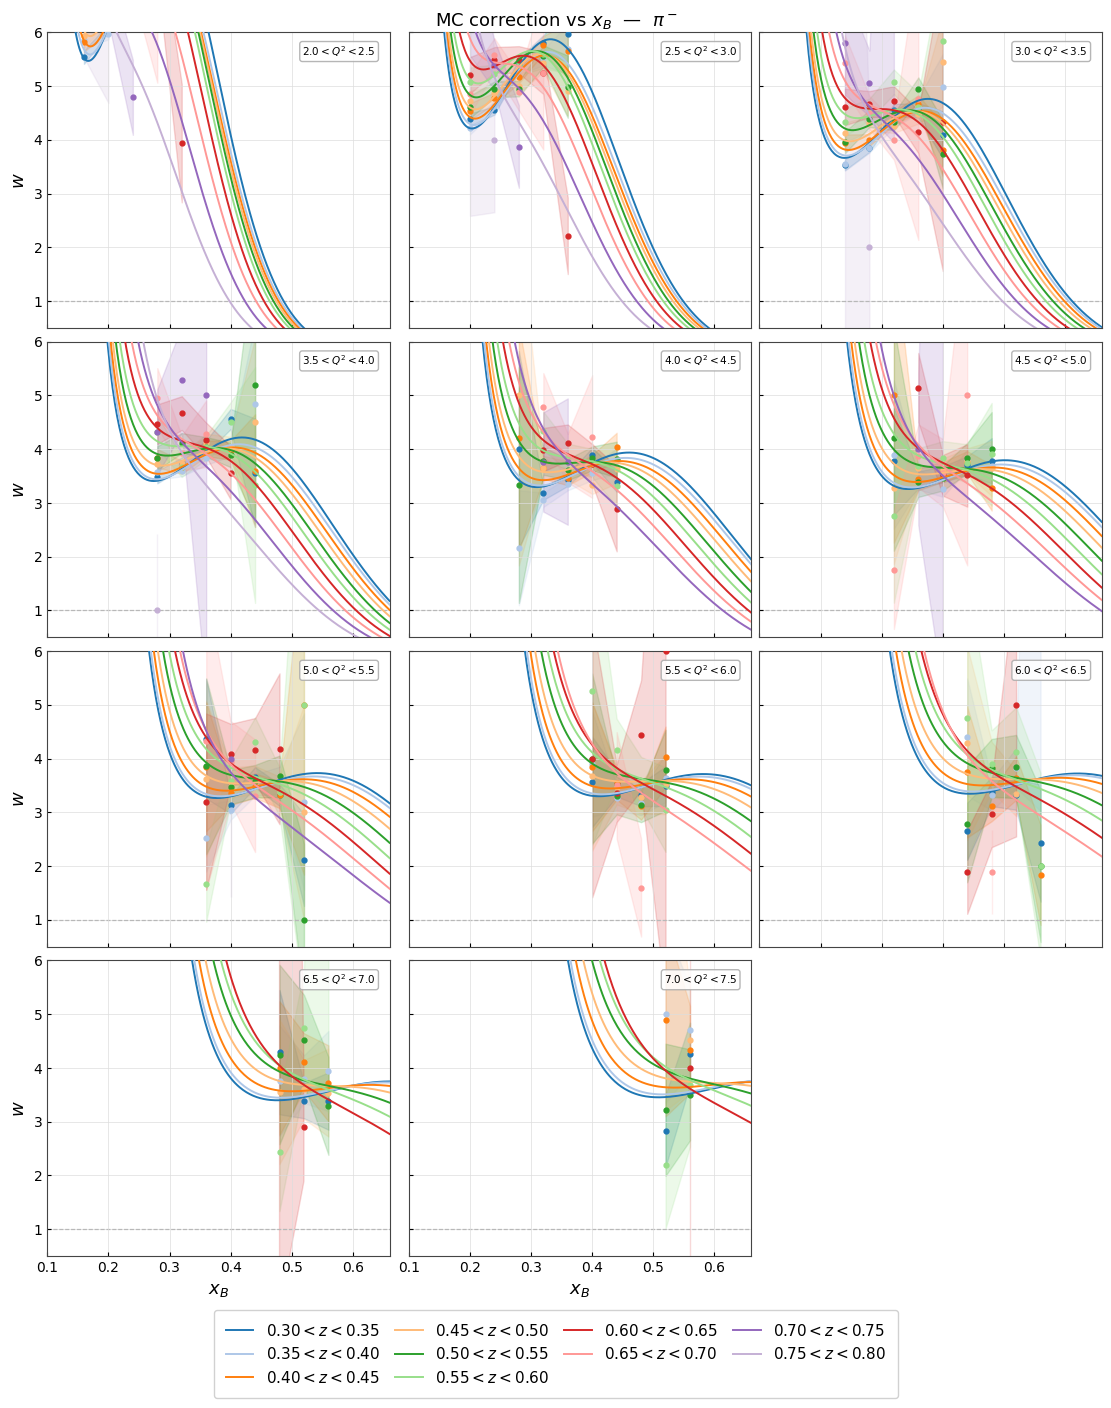

In [6]:
# ── Correction vs xB  (panels = Q2 bins, colours = z bins) ───────────────────
x_fine = np.linspace(xB_edges[0], xB_edges[-1], 300)

def plot_vs_xB(vals, errs, predict, sign_label, y_lim=Y_LIM):
    # Drop Q2 bins where no z slice has any finite data
    active_iq = [iq for iq in range(n_Q2)
                 if any(np.isfinite(vals[:, iq, iz]).any() for iz in range(n_z))]
    n_active = len(active_iq)

    ncols = 3
    nrows = math.ceil(n_active / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows),
                             constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(rf"MC correction vs $x_B$  —  {sign_label}", fontsize=13, y=1.01)
    axs_flat = np.array(axs).ravel()

    for panel, iq in enumerate(active_iq):
        ax = axs_flat[panel]
        panel_label(ax, rf"${Q2_edges[iq]:.1f} < Q^2 < {Q2_edges[iq+1]:.1f}$")

        for iz in range(n_z):
            c     = COLOR_LIST[iz]
            label = rf"${z_edges[iz]:.2f} < z < {z_edges[iz+1]:.2f}$"
            v, e  = vals[:, iq, iz], errs[:, iq, iz]
            mask  = np.isfinite(v) & np.isfinite(e)
            if not mask.any():
                continue
            z_fix = np.full_like(x_fine, z_centers[iz])
            q_fix = np.full_like(x_fine, Q2_centers[iq])

            ax.fill_between(xB_centers, v - e, v + e, color=c, alpha=0.18)
            ax.plot(xB_centers[mask], v[mask], "o", color=c, ms=3.5, zorder=3)
            ax.plot(x_fine, predict(z_fix, x_fine, q_fix),
                    color=c, lw=1.4, label=label, zorder=4)

        ax.axhline(1.0, color="#666666", lw=0.8, ls="--", zorder=1)
        ax.set_xlim(xB_edges[0], xB_edges[-1])
        ax.set_ylim(y_lim)
        col = panel % ncols
        row = panel // ncols
        if col == 0:
            ax.set_ylabel(r"$w$", fontsize=13)
        if row == nrows - 1:
            ax.set_xlabel(LABEL["xB"], fontsize=13)
        ax.tick_params(labelsize=10)

    for panel in range(n_active, nrows * ncols):
        axs_flat[panel].set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in axs_flat[:n_active]:
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc="upper center",
               bbox_to_anchor=(0.5, 0.0), ncol=4,
               fontsize=11, frameon=True, columnspacing=1.0,
               handlelength=1.8, borderpad=0.8)
    return fig

plot_vs_xB(vals_P, errs_P, pred_fac_P, r"$\pi^+$")
plt.show()
plot_vs_xB(vals_M, errs_M, pred_fac_M, r"$\pi^-$")
plt.show()


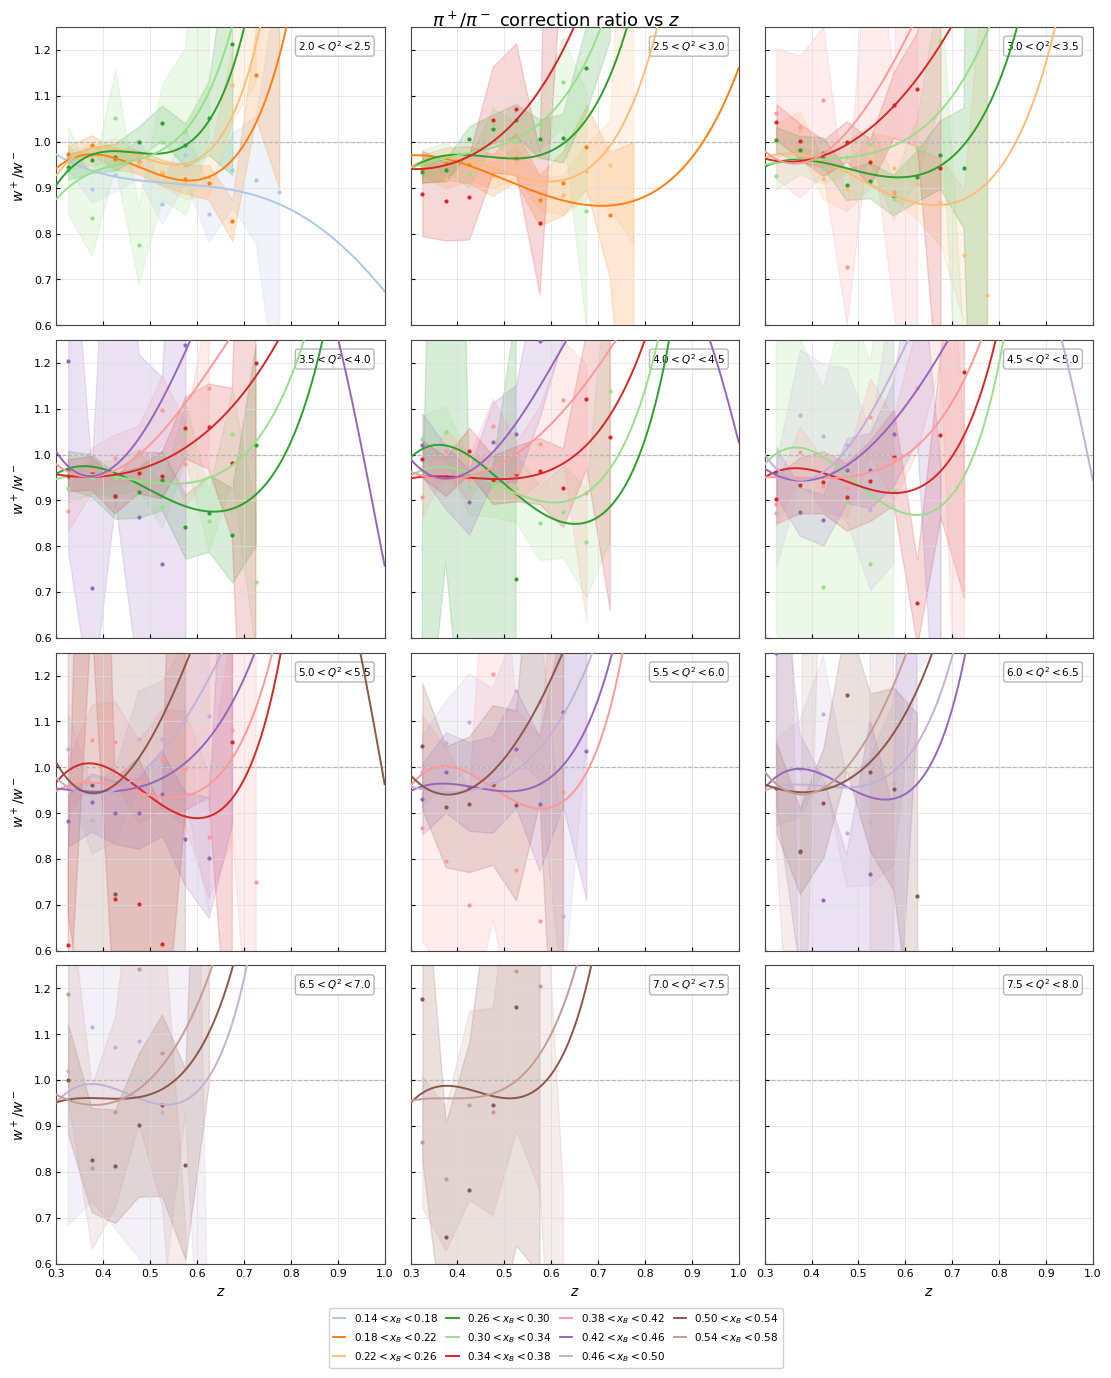

In [7]:
# ── π⁺ / π⁻ ratio vs z  (panels = Q2 bins, colours = xB bins) ───────────────
def plot_ratio_vs_z(vals_p, errs_p, vals_m, errs_m,
                    pred_p, pred_m, y_lim=Y_LIM_RATIO):
    ncols = 3
    nrows = math.ceil(n_Q2 / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows),
                             constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(r'$\pi^+/\pi^-$ correction ratio vs $z$', fontsize=13, y=1.01)

    for iq in range(n_Q2):
        row, col = divmod(iq, ncols)
        ax = axs[row, col]
        panel_label(ax, rf'${Q2_edges[iq]:.1f} < Q^2 < {Q2_edges[iq+1]:.1f}$')

        for ix in range(n_xB):
            vp, ep = vals_p[ix, iq, :], errs_p[ix, iq, :]
            vm, em = vals_m[ix, iq, :], errs_m[ix, iq, :]
            # need both charges valid
            mask = (np.isfinite(vp) & np.isfinite(vm) &
                    np.isfinite(ep) & np.isfinite(em) &
                    (vm > 0) & (ep > 0) & (em > 0))
            if not mask.any():
                continue

            ratio = np.where(mask, vp / vm, np.nan)
            # error propagation: σ_R/R = sqrt((σ+/C+)² + (σ-/C-)²)
            err   = np.where(mask,
                             ratio * np.sqrt((ep / vp)**2 + (em / vm)**2),
                             np.nan)

            c     = COLOR_LIST[ix]
            label = rf'${xB_edges[ix]:.2f} < x_B < {xB_edges[ix+1]:.2f}$'
            ax.fill_between(z_centers, ratio - err, ratio + err,
                            color=c, alpha=0.18)
            ax.plot(z_centers[mask], ratio[mask], 'o', color=c, ms=2, zorder=3)

            # continuous fit ratio
            x_fix = np.full_like(z_fine, xB_centers[ix])
            q_fix = np.full_like(z_fine, Q2_centers[iq])
            fit_ratio = pred_p(z_fine, x_fix, q_fix) / pred_m(z_fine, x_fix, q_fix)
            ax.plot(z_fine, fit_ratio, color=c, lw=1.4, label=label, zorder=4)

        ax.axhline(1.0, color='#666666', lw=0.8, ls='--', zorder=1)
        ax.set_xlim(z_edges[0], z_edges[-1])
        ax.set_ylim([.6,1.25])#y_lim)
        if col == 0:
            ax.set_ylabel(r'$w^+/w^-$', fontsize=10)
        if row == nrows - 1:
            ax.set_xlabel(LABEL['z'], fontsize=10)

    for iq in range(n_Q2, nrows * ncols):
        axs.ravel()[iq].set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in np.array(axs).ravel():
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=4,
               fontsize=7.5, frameon=True, columnspacing=0.8, handlelength=1.2)
    return fig

plot_ratio_vs_z(vals_P, errs_P, vals_M, errs_M, pred_fac_P, pred_fac_M)
plt.show()

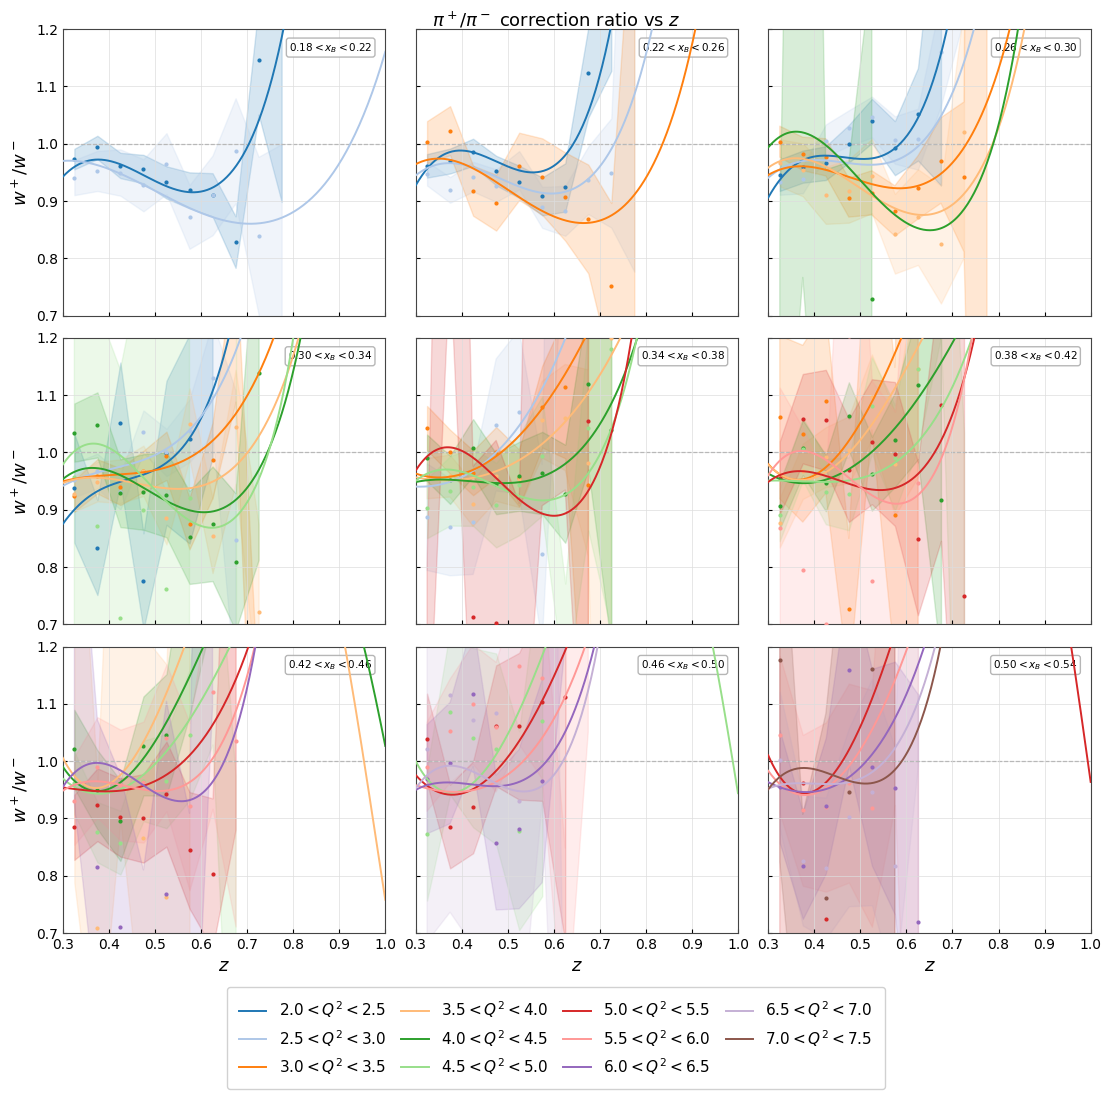

In [8]:
# ── π⁺ / π⁻ ratio vs z  (panels = xB bins, colours = Q2 bins) ───────────────
def plot_ratio_vs_z_q2(vals_p, errs_p, vals_m, errs_m,
                       pred_p, pred_m, y_lim=Y_LIM_RATIO):
    # Drop xB bins where no Q2 slice has any finite data in either charge
    active_ix = [ix for ix in range(n_xB)
                 if any(np.isfinite(vals_p[ix, iq, :]).any() or
                        np.isfinite(vals_m[ix, iq, :]).any()
                        for iq in range(n_Q2))]
    active_ix = active_ix[1:-1]  # remove first and last (empty boundary bins)
    n_active = len(active_ix)

    ncols = 3
    nrows = math.ceil(n_active / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows),
                             constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(r'$\pi^+/\pi^-$ correction ratio vs $z$', fontsize=13, y=1.01)
    axs_flat = np.array(axs).ravel()

    for panel, ix in enumerate(active_ix):
        ax = axs_flat[panel]
        panel_label(ax, rf'${xB_edges[ix]:.2f} < x_B < {xB_edges[ix+1]:.2f}$')

        for iq in range(n_Q2):
            vp, ep = vals_p[ix, iq, :], errs_p[ix, iq, :]
            vm, em = vals_m[ix, iq, :], errs_m[ix, iq, :]
            mask = (np.isfinite(vp) & np.isfinite(vm) &
                    np.isfinite(ep) & np.isfinite(em) &
                    (vm > 0) & (ep > 0) & (em > 0))
            if not mask.any():
                continue

            ratio = np.where(mask, vp / vm, np.nan)
            err   = np.where(mask,
                             ratio * np.sqrt((ep / vp)**2 + (em / vm)**2),
                             np.nan)

            c     = COLOR_LIST[iq]
            label = rf'${Q2_edges[iq]:.1f} < Q^2 < {Q2_edges[iq+1]:.1f}$'
            ax.fill_between(z_centers, ratio - err, ratio + err,
                            color=c, alpha=0.18)
            ax.plot(z_centers[mask], ratio[mask], 'o', color=c, ms=2, zorder=3)

            x_fix = np.full_like(z_fine, xB_centers[ix])
            q_fix = np.full_like(z_fine, Q2_centers[iq])
            fit_ratio = pred_p(z_fine, x_fix, q_fix) / pred_m(z_fine, x_fix, q_fix)
            ax.plot(z_fine, fit_ratio, color=c, lw=1.4, label=label, zorder=4)

        ax.axhline(1.0, color='#666666', lw=0.8, ls='--', zorder=1)
        ax.set_xlim(z_edges[0], z_edges[-1])
        ax.set_ylim([.7, 1.2])
        col = panel % ncols
        row = panel // ncols
        if col == 0:
            ax.set_ylabel(r'$w^+/w^-$', fontsize=13)
        if row == nrows - 1:
            ax.set_xlabel(LABEL['z'], fontsize=13)
        ax.tick_params(labelsize=10)

    for panel in range(n_active, nrows * ncols):
        axs_flat[panel].set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in axs_flat[:n_active]:
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=4,
               fontsize=11, frameon=True, columnspacing=1.0,
               handlelength=1.8, borderpad=0.8)
    return fig

plot_ratio_vs_z_q2(vals_P, errs_P, vals_M, errs_M, pred_fac_P, pred_fac_M)
plt.show()


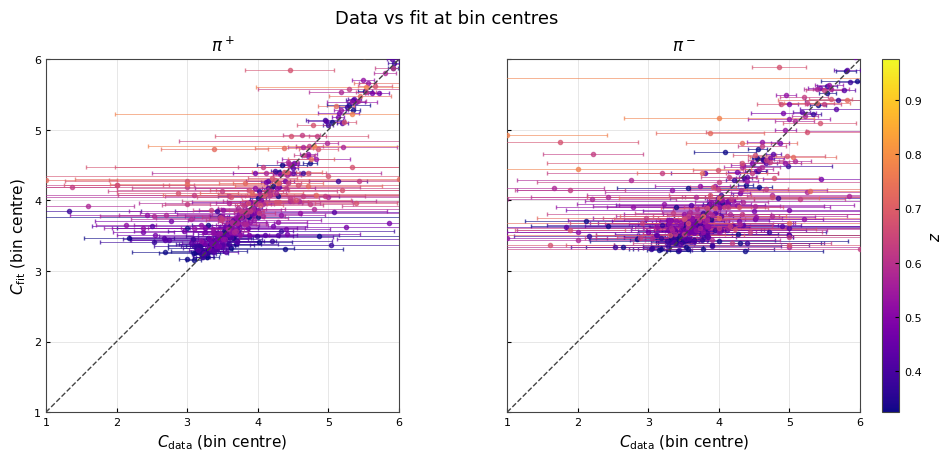

In [9]:
# ── Parity plot: data at bin centres vs fit at bin centres ────────────────────
def parity_plot(vals_p, errs_p, pred_p,
                vals_m, errs_m, pred_m, y_lim=(1, 6)):
    """
    For every finite (xB, Q2, z) bin, plot C_data vs C_fit.
    Points lie on the diagonal if the fit is perfect.
    Colour encodes z; marker size encodes 1/σ so well-constrained bins stand out.
    """
    z_norm = (z_centers - z_centers.min()) / (z_centers.max() - z_centers.min())
    cmap   = plt.get_cmap('plasma')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5),
                              constrained_layout=True, sharey=True)

    for ax, vals, errs, predict, sign_label in [
        (axes[0], vals_p, errs_p, pred_p, r'$\pi^+$'),
        (axes[1], vals_m, errs_m, pred_m, r'$\pi^-$'),
    ]:
        for iz in range(n_z):
            color = cmap(z_norm[iz])
            for ix, iq in iproduct(range(n_xB), range(n_Q2)):
                v = vals[ix, iq, iz]
                e = errs[ix, iq, iz]
                if not (np.isfinite(v) and np.isfinite(e) and v > 0 and e > 0):
                    continue
                f = predict(
                    np.array([z_centers[iz]]),
                    np.array([xB_centers[ix]]),
                    np.array([Q2_centers[iq]])
                )[0]
                ax.errorbar(v, f, xerr=e,
                            fmt='o', color=color,
                            ms=3, lw=0.6, capsize=1.5,
                            alpha=0.7, zorder=3)

        lim = y_lim
        ax.plot(lim, lim, color='#444444', lw=1, ls='--', zorder=4)
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_aspect('equal')
        ax.set_xlabel(r'$C_{\mathrm{data}}$ (bin centre)', fontsize=11)
        ax.set_title(sign_label, fontsize=12)

    axes[0].set_ylabel(r'$C_{\mathrm{fit}}$ (bin centre)', fontsize=11)
    fig.suptitle('Data vs fit at bin centres', fontsize=13)

    # Colorbar for z
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(z_centers.min(), z_centers.max()))
    sm.set_array([])
    cb = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
    cb.set_label(LABEL['z'], fontsize=11)
    cb.ax.tick_params(labelsize=8)

    return fig

parity_plot(vals_P, errs_P, pred_fac_P,
            vals_M, errs_M, pred_fac_M)
plt.show()

In [10]:
# ── Degree optimisation: full grid scan over DEG_P, DEG_R, DEG_ZQ, DEG_ZX ───
import io, contextlib

SCAN_DEG_P  = [1, 2, 3]
SCAN_DEG_R  = [1, 2, 3]
SCAN_DEG_ZQ = [0, 1, 2, 3]
SCAN_DEG_ZX = [0, 1, 2, 3]


def _chi2_ndof(vals, errs, pred, n_par):
    """Log-space χ²/ndof:  Σ (ln C_data − ln C_fit)² / (σ_C/C)²  / ndof."""
    chi2, n = 0.0, 0
    for ix, iq, iz in iproduct(range(n_xB), range(n_Q2), range(n_z)):
        v = vals[ix, iq, iz];  e = errs[ix, iq, iz]
        if not (np.isfinite(v) and np.isfinite(e) and v > 0 and e > 0):
            continue
        ln_f = pred.lnc(np.array([z_centers[iz]]),
                        np.array([xB_centers[ix]]),
                        np.array([Q2_centers[iq]]))[0]
        if not np.isfinite(ln_f):
            continue
        chi2 += ((np.log(v) - ln_f) / (e / v)) ** 2
        n    += 1
    ndof = n - n_par
    return chi2 / ndof if ndof > 0 else np.nan


def _fit_silent(vals, errs, dp, dr, dzq, dzx):
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            _, _, pred, n_par = fit_factorized(
                vals, errs, deg_p=dp, deg_r=dr, deg_zq=dzq, deg_zx=dzx)
        return pred, n_par
    except Exception:
        return None, 0


# ── Run scan ──────────────────────────────────────────────────────────────────
scan_results = {}   # (dp, dr, dzq, dzx) → {'chi2': avg, 'n_par': int}
combos = list(iproduct(SCAN_DEG_P, SCAN_DEG_R, SCAN_DEG_ZQ, SCAN_DEG_ZX))
print(f'Scanning {len(combos)} combinations '
      f'({len(SCAN_DEG_P)}×{len(SCAN_DEG_R)}×{len(SCAN_DEG_ZQ)}×{len(SCAN_DEG_ZX)})...\n')

for i, (dp, dr, dzq, dzx) in enumerate(combos):
    pred_p, np_ = _fit_silent(vals_P, errs_P, dp, dr, dzq, dzx)
    pred_m, nm_ = _fit_silent(vals_M, errs_M, dp, dr, dzq, dzx)
    if pred_p is None or pred_m is None:
        avg = np.nan
    else:
        r2p = _chi2_ndof(vals_P, errs_P, pred_p, np_)
        r2m = _chi2_ndof(vals_M, errs_M, pred_m, nm_)
        avg = (r2p + r2m) / 2 if (np.isfinite(r2p) and np.isfinite(r2m)) else np.nan
    scan_results[(dp, dr, dzq, dzx)] = {'chi2': avg, 'n_par': np_}
    print(f'  [{i+1:3d}/{len(combos)}]  '
          f'deg_p={dp}  deg_r={dr}  deg_zq={dzq}  deg_zx={dzx}  '
          f'χ²/ndof={avg:.4f}  n_par={np_}')

# ── Print optimum ─────────────────────────────────────────────────────────────
best_key = min(scan_results,
               key=lambda k: scan_results[k]['chi2']
               if np.isfinite(scan_results[k]['chi2']) else np.inf)
best = scan_results[best_key]
print(f'\n{"─"*60}')
print(f'Best  χ²/ndof = {best["chi2"]:.4f}  (n_params={best["n_par"]})')
print(f'  DEG_P  = {best_key[0]}')
print(f'  DEG_R  = {best_key[1]}')
print(f'  DEG_ZQ = {best_key[2]}')
print(f'  DEG_ZX = {best_key[3]}')
print(f'\nCopy into cell-01 to use:')
print(f'  DEG_P  = {best_key[0]}')
print(f'  DEG_R  = {best_key[1]}')
print(f'  DEG_ZQ = {best_key[2]}')
print(f'  DEG_ZX = {best_key[3]}')

Scanning 144 combinations (3×3×4×4)...

  [  1/144]  deg_p=1  deg_r=1  deg_zq=0  deg_zx=0  χ²/ndof=7.2406  n_par=4
  [  2/144]  deg_p=1  deg_r=1  deg_zq=0  deg_zx=1  χ²/ndof=7.1893  n_par=5
  [  3/144]  deg_p=1  deg_r=1  deg_zq=0  deg_zx=2  χ²/ndof=6.0580  n_par=6
  [  4/144]  deg_p=1  deg_r=1  deg_zq=0  deg_zx=3  χ²/ndof=5.4625  n_par=7
  [  5/144]  deg_p=1  deg_r=1  deg_zq=1  deg_zx=0  χ²/ndof=7.2532  n_par=5
  [  6/144]  deg_p=1  deg_r=1  deg_zq=1  deg_zx=1  χ²/ndof=7.0794  n_par=6
  [  7/144]  deg_p=1  deg_r=1  deg_zq=1  deg_zx=2  χ²/ndof=5.7377  n_par=7
  [  8/144]  deg_p=1  deg_r=1  deg_zq=1  deg_zx=3  χ²/ndof=5.1538  n_par=8
  [  9/144]  deg_p=1  deg_r=1  deg_zq=2  deg_zx=0  χ²/ndof=2.7911  n_par=6
  [ 10/144]  deg_p=1  deg_r=1  deg_zq=2  deg_zx=1  χ²/ndof=2.5700  n_par=7
  [ 11/144]  deg_p=1  deg_r=1  deg_zq=2  deg_zx=2  χ²/ndof=2.4743  n_par=8
  [ 12/144]  deg_p=1  deg_r=1  deg_zq=2  deg_zx=3  χ²/ndof=2.4092  n_par=9
  [ 13/144]  deg_p=1  deg_r=1  deg_zq=3  deg_zx=0  χ²/ndof=2

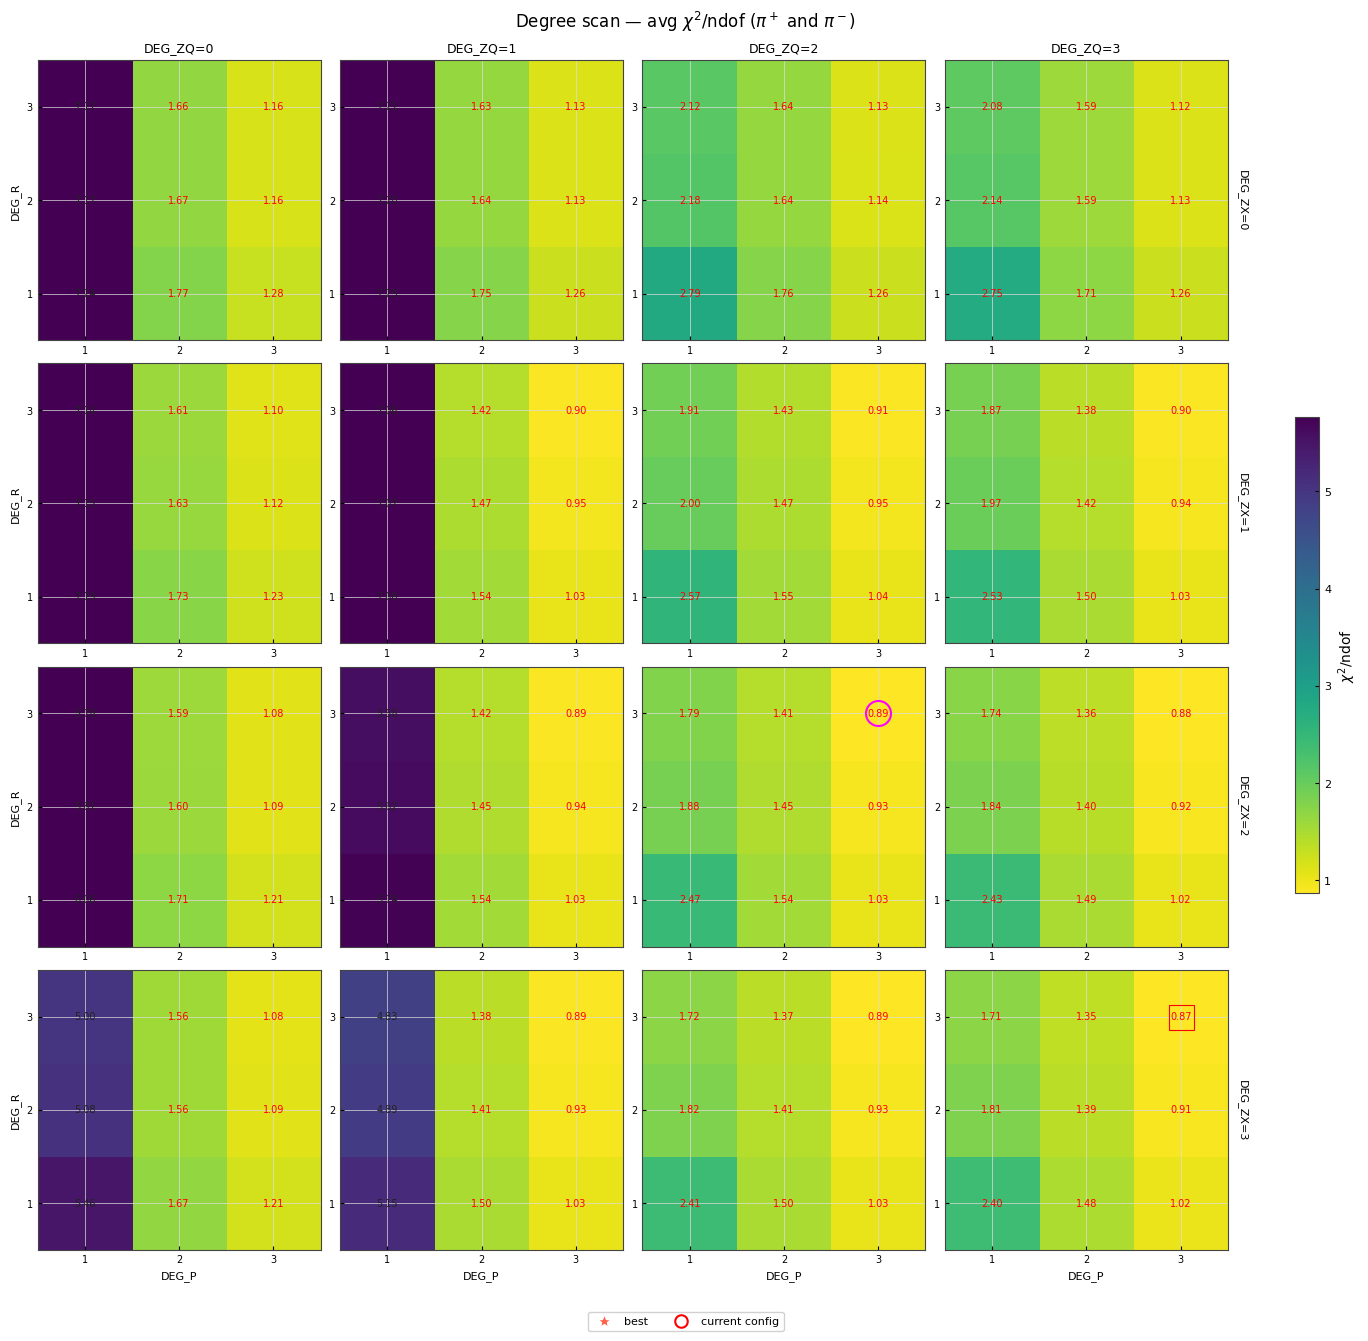

In [11]:
# ── Scan results: heatmap grid of χ²/ndof ────────────────────────────────────
#
# Layout: rows = DEG_ZX values, cols = DEG_ZQ values.
# Each panel: heatmap of DEG_P (x) × DEG_R (y).
# Red star = global best;  white circle = current config from cell-01.

n_dzx = len(SCAN_DEG_ZX)
n_dzq = len(SCAN_DEG_ZQ)

fig, axs = plt.subplots(n_dzx, n_dzq,
                         figsize=(3.4 * n_dzq, 3.2 * n_dzx),
                         constrained_layout=True,
                         squeeze=False)

fig.suptitle(r'Degree scan — avg $\chi^2/\mathrm{ndof}$ ($\pi^+$ and $\pi^-$)',
             fontsize=12)

# Shared colour scale: min to 90th-percentile of finite values
all_chi2 = np.array([scan_results[k]['chi2'] for k in scan_results])
finite   = all_chi2[np.isfinite(all_chi2)]
vmin     = finite.min()        if len(finite) else 0
vmax     = np.percentile(finite, 90) if len(finite) else 1

last_im = None
for ri, dzx in enumerate(SCAN_DEG_ZX):
    for ci, dzq in enumerate(SCAN_DEG_ZQ):
        ax = axs[ri, ci]

        mat = np.full((len(SCAN_DEG_R), len(SCAN_DEG_P)), np.nan)
        for rj, dr in enumerate(SCAN_DEG_R):
            for pj, dp in enumerate(SCAN_DEG_P):
                mat[rj, pj] = scan_results[(dp, dr, dzq, dzx)]['chi2']

        im = ax.imshow(mat, aspect='auto', origin='lower',
                       vmin=vmin, vmax=vmax, cmap='viridis_r')
        last_im = im

        # Annotate cells
        mid = (vmin + vmax) / 2
        for rj in range(len(SCAN_DEG_R)):
            for pj in range(len(SCAN_DEG_P)):
                v = mat[rj, pj]
                if np.isfinite(v):
                    ax.text(pj, rj, f'{v:.2f}', ha='center', va='center',
                            fontsize=7, color='red' if v < mid else '#222')

        # Global best
        if best_key[2] == dzq and best_key[3] == dzx:
            pj = SCAN_DEG_P.index(best_key[0])
            rj = SCAN_DEG_R.index(best_key[1])
            ax.plot(pj, rj, 's', ms=18, color='none',
                    markeredgecolor='red', markeredgewidth=0.8, zorder=5)

        # Current config
        if (DEG_ZQ == dzq and DEG_ZX == dzx
                and DEG_P in SCAN_DEG_P and DEG_R in SCAN_DEG_R):
            pj = SCAN_DEG_P.index(DEG_P)
            rj = SCAN_DEG_R.index(DEG_R)
            ax.plot(pj, rj, 'o', ms=18, color='none',
                    markeredgecolor='magenta', markeredgewidth=1.5, zorder=5)

        ax.set_xticks(range(len(SCAN_DEG_P))); ax.set_xticklabels(SCAN_DEG_P)
        ax.set_yticks(range(len(SCAN_DEG_R))); ax.set_yticklabels(SCAN_DEG_R)
        ax.tick_params(labelsize=7)

        # Axis labels on edges only
        if ri == n_dzx - 1: ax.set_xlabel('DEG_P', fontsize=8)
        if ci == 0:         ax.set_ylabel('DEG_R', fontsize=8)

        # Column header (DEG_ZQ) on top row
        if ri == 0: ax.set_title(f'DEG_ZQ={dzq}', fontsize=9)
        # Row label (DEG_ZX) on right edge
        if ci == n_dzq - 1:
            ax.annotate(f'DEG_ZX={dzx}', xy=(1.03, 0.5),
                        xycoords='axes fraction', rotation=-90,
                        va='center', ha='left', fontsize=8)

if last_im is not None:
    fig.colorbar(last_im, ax=axs, fraction=0.02, pad=0.04,
                 label=r'$\chi^2/\mathrm{ndof}$')

handles = [
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='tomato',
               markersize=10, label='best'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
               markeredgecolor='red', markeredgewidth=1.5,
               markersize=9, label='current config'),
]
fig.legend(handles=handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), ncol=2, fontsize=8)
plt.show()

In [12]:
# ── Write fit results to ROOT file ────────────────────────────────────────────
#
# Written histograms (all TH3F, axes = [xB, Q², z]):
#
#   hMcCorrectionP              original (possibly smoothed) π⁺ correction
#   hMcCorrectionM              original (possibly smoothed) π⁻ correction
#   hMcCorrectionP_fit          fit C evaluated at every bin centre
#   hMcCorrectionM_fit          fit C evaluated at every bin centre
#   hMcCorrectionP_fit_sigma    analytic 1-sigma uncertainty on fit C  (σ_C = C·σ_{lnC})
#   hMcCorrectionM_fit_sigma    analytic 1-sigma uncertainty on fit C
#   hMcCorrectionP_ratio        data / fit  (≈1 where fit is good)
#   hMcCorrectionM_ratio        data / fit

import boost_histogram as bh


def _eval_grid(fn):
    """Evaluate fn(z, x, q) on the full (n_xB, n_Q2, n_z) bin-centre grid."""
    zg  = z_centers[np.newaxis, np.newaxis, :]   * np.ones((n_xB, n_Q2, n_z))
    xg  = xB_centers[:, np.newaxis, np.newaxis]  * np.ones((n_xB, n_Q2, n_z))
    qg  = Q2_centers[np.newaxis, :, np.newaxis]  * np.ones((n_xB, n_Q2, n_z))
    return fn(zg, xg, qg).reshape(n_xB, n_Q2, n_z)


def _make_bh3(values, variances):
    """
    Build a boost_histogram TH3F-equivalent from (n_xB, n_Q2, n_z) arrays.
    NaN bins are stored as (0, 0) — ROOT convention for empty bins.
    """
    h = bh.Histogram(
        bh.axis.Variable(xB_edges),
        bh.axis.Variable(Q2_edges),
        bh.axis.Variable(z_edges),
        storage=bh.storage.Weight(),
    )
    h.view().value    = np.nan_to_num(values,   nan=0.0)
    h.view().variance = np.nan_to_num(variances, nan=0.0)
    return h


def write_corrections(output_path,
                      vals_p, errs_p, pred_p,
                      vals_m, errs_m, pred_m):
    """
    Evaluate fits and uncertainties on the bin-centre grid and write to ROOT.

    Fit uncertainty is analytic: σ_C = C · sqrt(xᵀ V x)  where V is the
    coefficient covariance matrix from the WLS (exact for a linear model).
    """
    print(f'Evaluating fits on {n_xB}×{n_Q2}×{n_z} grid...')
    fit_p   = _eval_grid(pred_p)
    fit_m   = _eval_grid(pred_m)
    sigma_p = _eval_grid(pred_p.sigma_C)   # σ_C = C · σ_{ln C}
    sigma_m = _eval_grid(pred_m.sigma_C)

    with np.errstate(invalid='ignore', divide='ignore'):
        ratio_p = np.where(np.isfinite(vals_p) & np.isfinite(fit_p) & (fit_p > 0),
                           vals_p / fit_p, np.nan)
        ratio_m = np.where(np.isfinite(vals_m) & np.isfinite(fit_m) & (fit_m > 0),
                           vals_m / fit_m, np.nan)
        ratio_err_p = np.where(np.isfinite(ratio_p),
                               ratio_p * (errs_p / vals_p), np.nan)
        ratio_err_m = np.where(np.isfinite(ratio_m),
                               ratio_m * (errs_m / vals_m), np.nan)

    print(f'Writing to {output_path} ...')
    with uproot.recreate(output_path) as f:
        f['hMcCorrectionP']           = _make_bh3(vals_p,   errs_p**2)
        f['hMcCorrectionM']           = _make_bh3(vals_m,   errs_m**2)
        f['hMcCorrectionP_fit']       = _make_bh3(fit_p,    sigma_p**2)
        f['hMcCorrectionM_fit']       = _make_bh3(fit_m,    sigma_m**2)
        f['hMcCorrectionP_fit_sigma'] = _make_bh3(sigma_p,  np.zeros_like(sigma_p))
        f['hMcCorrectionM_fit_sigma'] = _make_bh3(sigma_m,  np.zeros_like(sigma_m))
        f['hMcCorrectionP_ratio']     = _make_bh3(ratio_p,  ratio_err_p**2)
        f['hMcCorrectionM_ratio']     = _make_bh3(ratio_m,  ratio_err_m**2)

    print('Done.  Histograms written:')
    for name in ['hMcCorrectionP', 'hMcCorrectionM',
                 'hMcCorrectionP_fit', 'hMcCorrectionM_fit',
                 'hMcCorrectionP_fit_sigma', 'hMcCorrectionM_fit_sigma',
                 'hMcCorrectionP_ratio', 'hMcCorrectionM_ratio']:
        print(f'  {name}')


if OUTPUT_FILE:
    write_corrections(OUTPUT_FILE,
                      vals_P, errs_P, pred_fac_P,
                      vals_M, errs_M, pred_fac_M)
else:
    print('OUTPUT_FILE is None — skipping write.')

OUTPUT_FILE is None — skipping write.


In [13]:
# Write TF3 fit functions to ROOT file
#
# z features use the normalised power basis t^k where t = (z - z_mid) / z_rng,
# matching the Python fit exactly.
#
# TF3 variable convention:  x = xB,  y = Q2,  z = z (fragmentation)
# Usage in C++:
#   double corr  = wP ->Eval(xB, Q2, z);
#   double sigma = swP->Eval(xB, Q2, z);

def _pow_str(var, n):
    if n == 0: return None
    if n == 1: return var
    if n == 2: return f'{var}*{var}'
    return f'pow({var},{n})'


def _tz_str():
    """ROOT TFormula string for t = (z - _Z_MID) / _Z_RNG."""
    return f'((z-({_Z_MID:.15e}))/({_Z_RNG:.15e}))'


def _feature_str(i, j, k_z, m_lnq, n_lnx):
    """
    ROOT formula string for (ln x)^(i+n_lnx) * (ln y)^(j+m_lnq) * t^k_z
    where t = (z - _Z_MID) / _Z_RNG.
    """
    tz = _tz_str()
    parts = [_pow_str('log(x)', i + n_lnx),
             _pow_str('log(y)', j + m_lnq),
             _pow_str(tz,       k_z)]
    parts = [p for p in parts if p is not None]
    return '*'.join(parts) if parts else '1'


def _build_feature_strings(pt, zq_terms, zx_terms):
    feats = []
    for (i, j) in pt:
        feats.append(_feature_str(i, j, 0, 0, 0))
    for (k, m) in zq_terms:
        feats.append(_feature_str(0, 0, k, m, 0))
    for (k, n) in zx_terms:
        feats.append(_feature_str(0, 0, k, 0, n))
    return feats


def _build_tf3_formula(feat_strs, coeffs):
    terms = [f'({c:.15e})*{f}' if f != '1' else f'({c:.15e})'
             for c, f in zip(coeffs, feat_strs) if c != 0.0]
    inner = '+'.join(terms) if terms else '0'
    return f'exp({inner})'


def _build_tf3_sigma_formula(feat_strs, coeffs, cov):
    """
    sigma_C = C * sqrt( f^T V f )
    Uses Cholesky column formula: f^T V f = ||L^T f||^2 = sum_k (sum_i L[i,k]*f_i)^2
    """
    n = len(coeffs)
    try:
        L = np.linalg.cholesky(cov + np.eye(n) * 1e-14 * np.trace(cov) / n)
        use_chol = True
    except np.linalg.LinAlgError:
        use_chol = False

    lnC_inner = '+'.join(
        [f'({c:.15e})*{f}' if f != '1' else f'({c:.15e})'
         for c, f in zip(coeffs, feat_strs) if c != 0.0]
    ) or '0'

    if use_chol:
        sq_terms = []
        for k in range(n):
            col_terms = [f'({L[i,k]:.15e})*{feat_strs[i]}' if feat_strs[i] != '1'
                         else f'({L[i,k]:.15e})'
                         for i in range(k, n) if L[i, k] != 0.0]
            if not col_terms:
                continue
            inner_k = '+'.join(col_terms)
            sq_terms.append(f'({inner_k})*({inner_k})')
        var_str = '+'.join(sq_terms) if sq_terms else '0'
    else:
        cross = []
        for i in range(n):
            for j in range(n):
                v = cov[i, j]
                if v == 0.0: continue
                cross.append(f'({v:.15e})*{feat_strs[i]}*{feat_strs[j]}')
        var_str = '+'.join(cross) if cross else '0'

    return f'exp({lnC_inner})*sqrt(abs({var_str}))'


def _check_sigma_formula(pred, cov, label):
    z_t = np.array([0.5]);  x_t = np.array([0.15]);  q_t = np.array([2.0])
    sigma_py = pred.sigma(z_t, x_t, q_t)[0]
    pt_  = _p_terms(DEG_P)
    zq_  = [(k, m) for k in range(1, DEG_R+1) for m in range(DEG_ZQ+1)]
    zx_  = [(k, n) for k in range(1, DEG_R+1) for n in range(1, DEG_ZX+1)]
    f_   = _build_features(z_t, np.log(x_t), np.log(q_t), pt_, zq_, zx_)[0]
    var_quad = float(f_ @ cov @ f_)
    n = len(f_)
    L = np.linalg.cholesky(cov + np.eye(n) * 1e-14 * np.trace(cov) / n)
    var_col = float(np.sum((L.T @ f_)**2))
    var_row = float(np.sum((L   @ f_)**2))
    print(f'  {label}  sigma_lnC  python={sigma_py:.6e}  '
          f'quad={np.sqrt(var_quad):.6e}  '
          f'col={np.sqrt(var_col):.6e}  '
          f'row(wrong)={np.sqrt(var_row):.6e}')

print('Sanity check -- sigma_{ln C} at z=0.5, xB=0.15, Q2=2.0:')
_check_sigma_formula(pred_fac_P, pred_fac_P.cov, 'pi+')
_check_sigma_formula(pred_fac_M, pred_fac_M.cov, 'pi-')


def write_tf3(output_path, coeffs_p, cov_p, coeffs_m, cov_m,
              deg_p=None, deg_r=None, deg_zq=None, deg_zx=None):
    if deg_p  is None: deg_p  = DEG_P
    if deg_r  is None: deg_r  = DEG_R
    if deg_zq is None: deg_zq = DEG_ZQ
    if deg_zx is None: deg_zx = DEG_ZX

    pt       = _p_terms(deg_p)
    zq_terms = [(k, m) for k in range(1, deg_r + 1) for m in range(deg_zq + 1)]
    zx_terms = [(k, n) for k in range(1, deg_r + 1) for n in range(1, deg_zx + 1)]

    feat_strs = _build_feature_strings(pt, zq_terms, zx_terms)

    formula_p       = _build_tf3_formula(feat_strs, coeffs_p)
    formula_m       = _build_tf3_formula(feat_strs, coeffs_m)
    formula_sigma_p = _build_tf3_sigma_formula(feat_strs, coeffs_p, cov_p)
    formula_sigma_m = _build_tf3_sigma_formula(feat_strs, coeffs_m, cov_m)

    xlo, xhi = float(xB_edges[0]),  float(xB_edges[-1])
    ylo, yhi = float(Q2_edges[0]),  float(Q2_edges[-1])
    zlo, zhi = float(z_edges[0]),   float(z_edges[-1])

    try:
        import ROOT
        ROOT.gROOT.SetBatch(True)

        tf3_p  = ROOT.TF3('hMcCorrectionP_tf3',       formula_p,
                          xlo, xhi, ylo, yhi, zlo, zhi)
        tf3_m  = ROOT.TF3('hMcCorrectionM_tf3',       formula_m,
                          xlo, xhi, ylo, yhi, zlo, zhi)
        tf3_sp = ROOT.TF3('hMcCorrectionP_tf3_sigma', formula_sigma_p,
                          xlo, xhi, ylo, yhi, zlo, zhi)
        tf3_sm = ROOT.TF3('hMcCorrectionM_tf3_sigma', formula_sigma_m,
                          xlo, xhi, ylo, yhi, zlo, zhi)

        for tf, title in [
            (tf3_p,  'MC correction pi+;x_{B};Q^{2} [GeV^{2}];z'),
            (tf3_m,  'MC correction pi-;x_{B};Q^{2} [GeV^{2}];z'),
            (tf3_sp, 'sigma_C pi+;x_{B};Q^{2} [GeV^{2}];z'),
            (tf3_sm, 'sigma_C pi-;x_{B};Q^{2} [GeV^{2}];z'),
        ]:
            tf.SetTitle(title)

        f = ROOT.TFile.Open(output_path, 'UPDATE')
        for tf in [tf3_p, tf3_m, tf3_sp, tf3_sm]:
            tf.Write('', ROOT.TObject.kOverwrite)
        f.Close()

        print(f'TF3 objects written to {output_path}:')
        for name, fml in [('hMcCorrectionP_tf3',       formula_p),
                          ('hMcCorrectionM_tf3',       formula_m),
                          ('hMcCorrectionP_tf3_sigma', formula_sigma_p),
                          ('hMcCorrectionM_tf3_sigma', formula_sigma_m)]:
            print(f'  {name:<35s}  ({len(fml)} chars)')
        print('Usage in C++:')
        print('  TF3 *wP  = (TF3*) f->Get("hMcCorrectionP_tf3");')
        print('  double corr  = wP->Eval(xB, Q2, z);')

    except ImportError:
        print('PyROOT not available -- TF3 not written.')
        for name, fml in [('C pi+', formula_p), ('C pi-', formula_m),
                          ('sigma pi+', formula_sigma_p), ('sigma pi-', formula_sigma_m)]:
            print(f'  {name}: {fml[:200]}...')


if OUTPUT_FILE:
    write_tf3(OUTPUT_FILE, c_fac_P, pred_fac_P.cov, c_fac_M, pred_fac_M.cov)
else:
    print('OUTPUT_FILE is None — skipping TF3 write.')


Sanity check -- sigma_{ln C} at z=0.5, xB=0.15, Q2=2.0:
  pi+  sigma_lnC  python=1.731534e-02  quad=1.731534e-02  col=1.731570e-02  row(wrong)=1.516199e+01
  pi-  sigma_lnC  python=2.504507e-02  quad=2.504507e-02  col=2.504514e-02  row(wrong)=2.409747e+01
OUTPUT_FILE is None — skipping TF3 write.


In [14]:
# ── Write theta vectors, covariance matrices, and basis degrees ──────────────
#
# Appends eight objects to OUTPUT_FILE (UPDATE mode), required by the
# makeRatio3D_fullUnc executable to compute the full analytical
# uncertainty on the FF ratio.  This cell does NOT modify the fit logic
# or formalism — it only serializes the already-computed θ and V from
# fit_factorized() (cell 6) to the existing output ROOT file.
#
#   theta_McCorrectionP   TVectorD,    length M   (π⁺ fit coefficients)
#   theta_McCorrectionM   TVectorD,    length M   (π⁻ fit coefficients)
#   cov_McCorrectionP     TMatrixDSym, M × M      (π⁺ coefficient covariance)
#   cov_McCorrectionM     TMatrixDSym, M × M      (π⁻ coefficient covariance)
#   dP_McCorrection       TParameter<int>          (= DEG_P)
#   dR_McCorrection       TParameter<int>          (= DEG_R)
#   dZQ_McCorrection      TParameter<int>          (= DEG_ZQ)
#   dZX_McCorrection      TParameter<int>          (= DEG_ZX)
#
# Basis-vector ordering is identical to cells 6 and 15:
#   Block A: (ln xB)^i · (ln Q²)^j   for i+j ≤ deg_p
#   Block B: z^k · (ln Q²)^m          for k = 1..deg_r,  m = 0..deg_zq
#   Block C: z^k · (ln xB)^n          for k = 1..deg_r,  n = 1..deg_zx

def write_theta_cov(output_path,
                    coeffs_p, cov_p,
                    coeffs_m, cov_m,
                    deg_p, deg_r, deg_zq, deg_zx):
    """Append theta vectors + covariance matrices + basis degrees to a ROOT file."""
    try:
        import ROOT
    except ImportError:
        print('PyROOT not available — theta/cov objects not written to file.')
        return

    ROOT.gROOT.SetBatch(True)

    coeffs_p = np.asarray(coeffs_p, dtype=np.float64)
    coeffs_m = np.asarray(coeffs_m, dtype=np.float64)
    cov_p    = np.asarray(cov_p,    dtype=np.float64)
    cov_m    = np.asarray(cov_m,    dtype=np.float64)

    M = coeffs_p.shape[0]
    assert coeffs_m.shape[0] == M, \
        f'theta length mismatch: π⁺={coeffs_p.shape[0]}, π⁻={coeffs_m.shape[0]}'
    assert cov_p.shape == (M, M), f'cov_p shape {cov_p.shape} != ({M},{M})'
    assert cov_m.shape == (M, M), f'cov_m shape {cov_m.shape} != ({M},{M})'

    # ── Build TVectorD and TMatrixDSym objects (element-wise = portable) ──
    def _to_tvector(arr):
        v = ROOT.TVectorD(M)
        for i in range(M):
            v[i] = float(arr[i])
        return v

    def _to_tmatrix_sym(mat):
        # Symmetrize to suppress any floating-point asymmetry from the SVD.
        sym = 0.5 * (mat + mat.T)
        m   = ROOT.TMatrixDSym(M)
        for i in range(M):
            for j in range(M):
                m[i][j] = float(sym[i, j])
        return m

    theta_p = _to_tvector(coeffs_p)
    theta_m = _to_tvector(coeffs_m)
    Vp      = _to_tmatrix_sym(cov_p)
    Vm      = _to_tmatrix_sym(cov_m)

    # ── Basis-degree TParameters ──
    p_dP  = ROOT.TParameter('int')('dP_McCorrection',  int(deg_p))
    p_dR  = ROOT.TParameter('int')('dR_McCorrection',  int(deg_r))
    p_dZQ = ROOT.TParameter('int')('dZQ_McCorrection', int(deg_zq))
    p_dZX = ROOT.TParameter('int')('dZX_McCorrection', int(deg_zx))

    f = ROOT.TFile.Open(output_path, 'UPDATE')
    if not f or f.IsZombie():
        print(f'Could not open {output_path} in UPDATE mode.')
        return

    f.cd()
    theta_p.Write('theta_McCorrectionP', ROOT.TObject.kOverwrite)
    theta_m.Write('theta_McCorrectionM', ROOT.TObject.kOverwrite)
    Vp     .Write('cov_McCorrectionP',   ROOT.TObject.kOverwrite)
    Vm     .Write('cov_McCorrectionM',   ROOT.TObject.kOverwrite)
    # TParameter is its own TNamed; empty key keeps the constructor name.
    p_dP .Write('', ROOT.TObject.kOverwrite)
    p_dR .Write('', ROOT.TObject.kOverwrite)
    p_dZQ.Write('', ROOT.TObject.kOverwrite)
    p_dZX.Write('', ROOT.TObject.kOverwrite)
    f.Close()

    print(f'Wrote θ + V + degrees to {output_path}:')
    print(f'  theta_McCorrectionP   TVectorD,    length {M}')
    print(f'  theta_McCorrectionM   TVectorD,    length {M}')
    print(f'  cov_McCorrectionP     TMatrixDSym, {M} × {M}')
    print(f'  cov_McCorrectionM     TMatrixDSym, {M} × {M}')
    print(f'  dP_McCorrection       TParameter<int> = {deg_p}')
    print(f'  dR_McCorrection       TParameter<int> = {deg_r}')
    print(f'  dZQ_McCorrection      TParameter<int> = {deg_zq}')
    print(f'  dZX_McCorrection      TParameter<int> = {deg_zx}')


if OUTPUT_FILE:
    write_theta_cov(OUTPUT_FILE,
                    c_fac_P, pred_fac_P.cov,
                    c_fac_M, pred_fac_M.cov,
                    DEG_P, DEG_R, DEG_ZQ, DEG_ZX)
else:
    print('OUTPUT_FILE is None — skipping theta/cov write.')


OUTPUT_FILE is None — skipping theta/cov write.


In [15]:
# ── 4D correction file config ─────────────────────────────────────────────────
# FILE_4D   : output of calcCorrections_4D  (contains hMcCorrP_0 … hMcCorrP_N)
# OUT_4D    : where to write fit results (None = skip write)



In [16]:
# ── Load 4D file, read metadata, fit each var bin ────────────────────────────
# Requires fit_factorized, Predictor, and all helpers from cell-3 to be run.

with uproot.open(FILE_4D) as f4:
    n4d   = int(f4['n4d_bins'].members['fVal'])
    vmin4 = float(f4['var_min'].members['fVal'])
    vmax4 = float(f4['var_max'].members['fVal'])
    vname = f4['var_name'].members['fTitle']

    # Use first var-bin histogram to get axis edges (same for all bins)
    _h0 = f4['hMcCorrP_0']
    xB_edges4  = _h0.axes[0].edges()
    Q2_edges4  = _h0.axes[1].edges()
    z_edges4   = _h0.axes[2].edges()

    vals4_P = []
    errs4_P = []
    vals4_M = []
    errs4_M = []
    for pt in range(n4d):
        hP4 = f4[f'hMcCorrP_{pt}']
        hM4 = f4[f'hMcCorrM_{pt}']
        vP = hP4.values().copy();  eP = np.sqrt(hP4.variances())
        vM = hM4.values().copy();  eM = np.sqrt(hM4.variances())
        for v, e in [(vP, eP), (vM, eM)]:
            bad = ~(np.isfinite(v) & (v > 0) & np.isfinite(e) & (e > 0))
            v[bad] = np.nan;  e[bad] = np.nan
        vals4_P.append(vP);  errs4_P.append(eP)
        vals4_M.append(vM);  errs4_M.append(eM)

xB_centers4 = 0.5 * (xB_edges4[:-1] + xB_edges4[1:])
Q2_centers4 = 0.5 * (Q2_edges4[:-1] + Q2_edges4[1:])
z_centers4  = 0.5 * (z_edges4[:-1]  + z_edges4[1:])
n_xB4 = len(xB_centers4);  n_Q24 = len(Q2_centers4);  n_z4 = len(z_centers4)

# var bin centres
var_step4   = (vmax4 - vmin4) / n4d
var_centers4 = vmin4 + (np.arange(n4d) + 0.5) * var_step4

# Override z normalisation for these data
_Z_MID4 = 0.5 * (z_edges4[0] + z_edges4[-1])
_Z_RNG4 = 0.5 * (z_edges4[-1] - z_edges4[0])

# Temporarily redirect globals so fit_factorized uses the 4D axes
_save = (n_xB, n_Q2, n_z, xB_centers, Q2_centers, z_centers, _Z_MID, _Z_RNG)
n_xB = n_xB4;  n_Q2 = n_Q24;  n_z = n_z4
xB_centers = xB_centers4;  Q2_centers = Q2_centers4;  z_centers = z_centers4
_Z_MID = _Z_MID4;  _Z_RNG = _Z_RNG4

preds4_P = [];  preds4_M = []
for pt in range(n4d):
    lo = vmin4 + pt * var_step4;  hi = lo + var_step4
    print(f'Var bin {pt}  {vname} in [{lo:.3g}, {hi:.3g})')
    print('  π⁺ ...', end=' ')
    _, _, pred_P4, _ = fit_factorized(vals4_P[pt], errs4_P[pt])
    print('  π⁻ ...', end=' ')
    _, _, pred_M4, _ = fit_factorized(vals4_M[pt], errs4_M[pt])
    preds4_P.append(pred_P4);  preds4_M.append(pred_M4)

# Restore globals
(n_xB, n_Q2, n_z, xB_centers, Q2_centers, z_centers, _Z_MID, _Z_RNG) = _save
print(f'\nLoaded {n4d} var bins for "{vname}" in [{vmin4:.3g}, {vmax4:.3g}]')


Var bin 0  pT in [0, 0.3)
  π⁺ ...   deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=1.295  (399 bins, ndof=374)
  π⁻ ...   deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=1.009  (388 bins, ndof=363)
Var bin 1  pT in [0.3, 0.6)
  π⁺ ...   deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=2.160  (386 bins, ndof=361)
  π⁻ ...   deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=1.139  (375 bins, ndof=350)
Var bin 2  pT in [0.6, 0.9)
  π⁺ ...   deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=1.819  (312 bins, ndof=287)
  π⁻ ...   deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=0.981  (302 bins, ndof=277)
Var bin 3  pT in [0.9, 1.2)
  π⁺ ...   deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=0.854  (125 bins, ndof=100)
  π⁻ ...   deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=0.765  (126 bins, ndof=101)
Var bin 4  pT in [1.2, 1.5)
  π⁺ ...   deg_p=3 deg_r=3 deg_zq=2 deg_zx=2  n_par=25  χ²/ndof=nan  (14 bins, ndof=-11)
  π⁻ ...   deg_p=3 deg_r=3 deg_zq=2 d

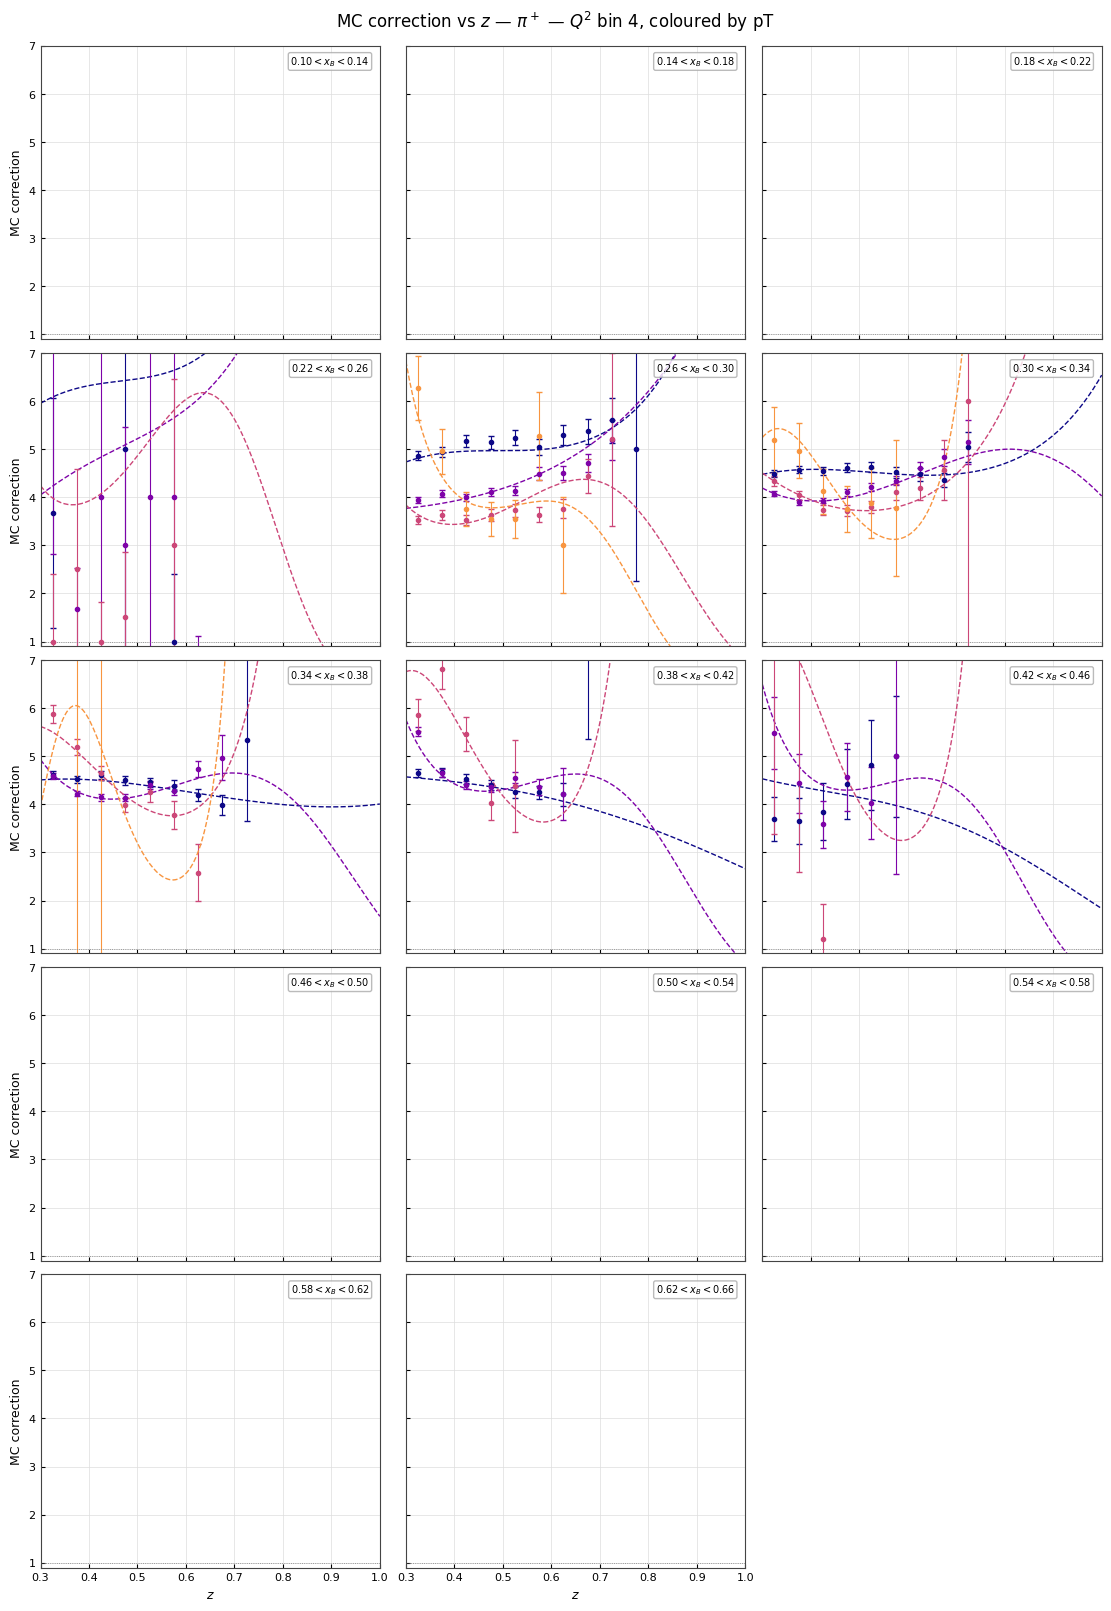

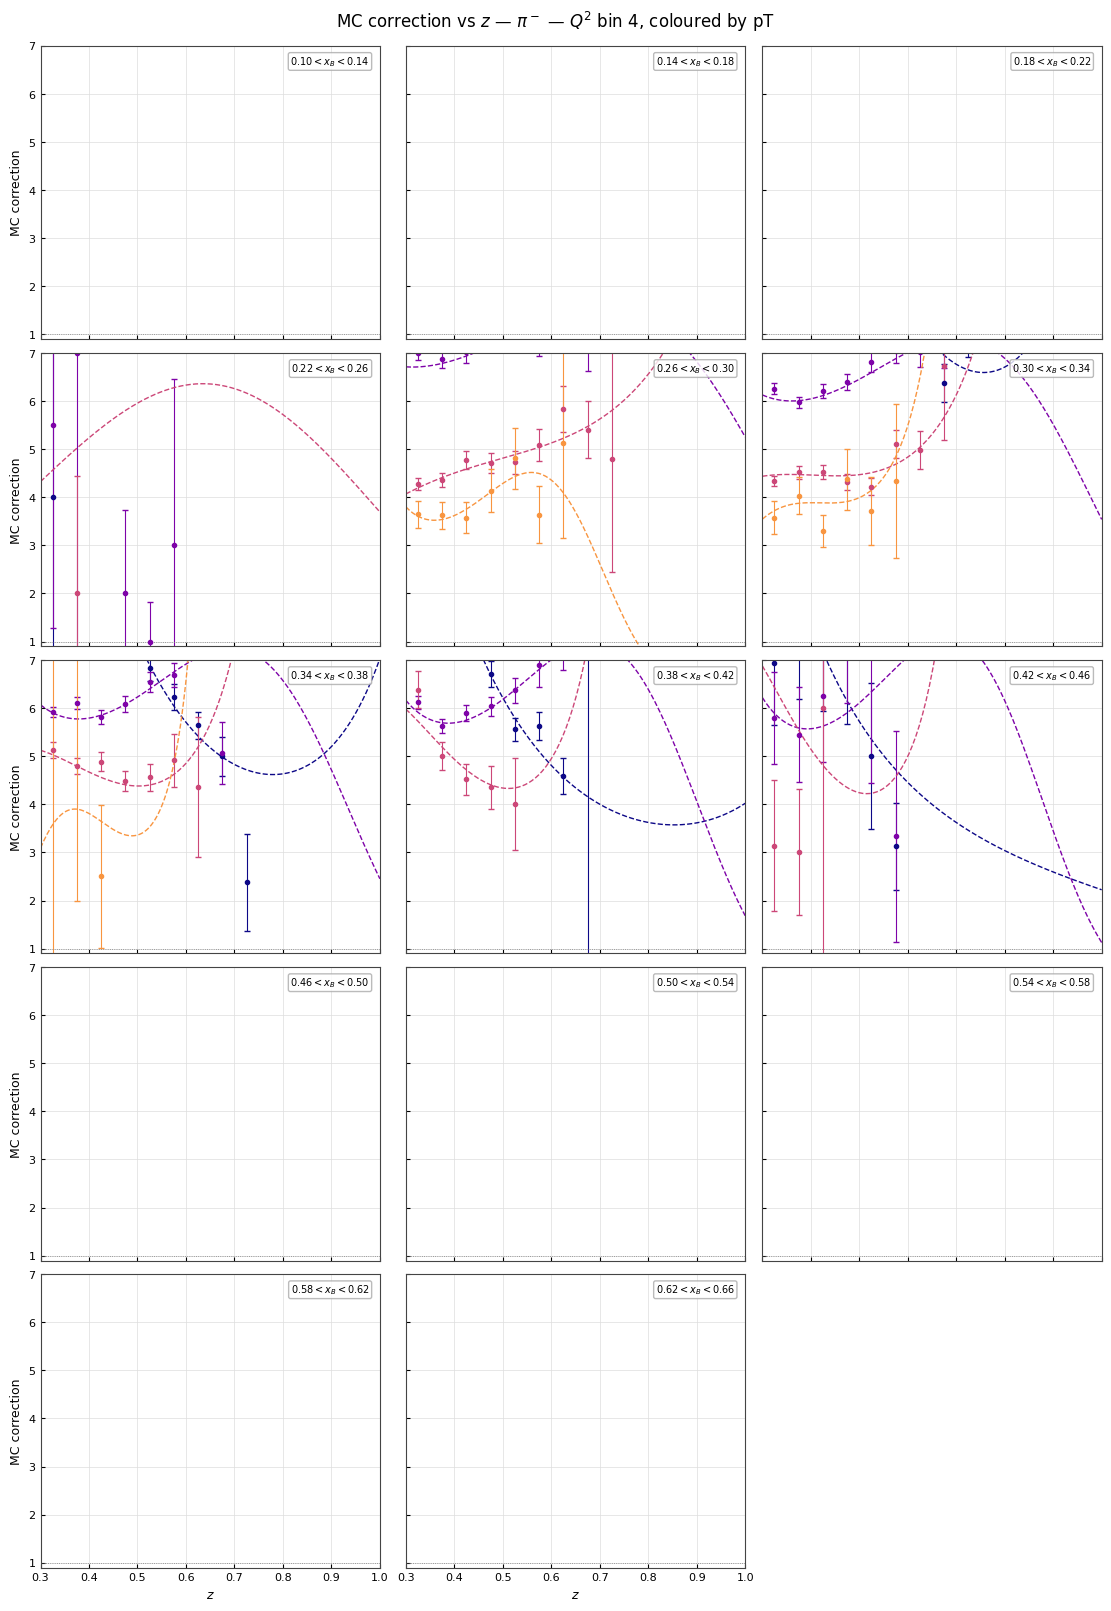

In [17]:
# ── Plot 4D corrections vs z: panels = xB bins, colours = var bins ───────────
# One figure for π⁺, one for π⁻.  Each panel overlays all var bins.
# Solid markers = data;  dashed curve = fit.

SHOW_VAR_BINS = list(range(n4d))  # subset to display, or range(n4d) for all
FIXED_Q2_BIN  = 3                 # which Q2 bin to show in the xB panels (0-based)

cmap4   = plt.get_cmap('plasma')
colors4 = [cmap4(pt / max(n4d - 1, 1)) for pt in range(n4d)]
z_fine4 = np.linspace(z_edges4[0], z_edges4[-1], 200)

for charge_label, vals4, errs4, preds4 in [
        (r'$\pi^+$', vals4_P, errs4_P, preds4_P),
        (r'$\pi^-$', vals4_M, errs4_M, preds4_M)]:

    ncols = 3
    nrows = math.ceil(n_xB4 / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows),
                             constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(rf'MC correction vs $z$ — {charge_label} — '
                 rf'$Q^2$ bin {FIXED_Q2_BIN+1}, coloured by {vname}',
                 fontsize=12)
    axs_flat = axs.ravel()

    for ix in range(n_xB4):
        ax = axs_flat[ix]
        lo = xB_edges4[ix];  hi = xB_edges4[ix + 1]
        ax.text(0.97, 0.97, rf'${lo:.2f}<x_B<{hi:.2f}$',
                transform=ax.transAxes, ha='right', va='top', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.8))

        for pt in SHOW_VAR_BINS:
            v = vals4[pt][ix, FIXED_Q2_BIN, :]
            e = errs4[pt][ix, FIXED_Q2_BIN, :]
            mask = np.isfinite(v)
            if not mask.any():
                continue
            col = colors4[pt]
            lbl = rf'{vname} $\in$ [{vmin4+pt*var_step4:.3g}, {vmin4+(pt+1)*var_step4:.3g})'
            ax.errorbar(z_centers4[mask], v[mask], e[mask],
                        fmt='o', color=col, markersize=3, capsize=2, lw=0.8, label=lbl)
            # fit curve
            xb_c = xB_centers4[ix];  q2_c = Q2_centers4[FIXED_Q2_BIN]
            fit_c = preds4[pt](z_fine4,
                                np.full_like(z_fine4, xb_c),
                                np.full_like(z_fine4, q2_c))
            ax.plot(z_fine4, fit_c, color=col, lw=1, ls='--')

        ax.set_xlim(z_edges4[0], z_edges4[-1])
        ax.set_ylim([.9,7])#*Y_LIM)
        ax.axhline(1, color='gray', lw=0.6, ls=':')
        ax.tick_params(labelsize=8)
        col_idx = ix % ncols;  row_idx = ix // ncols
        if col_idx == 0: ax.set_ylabel('MC correction', fontsize=9)
        if row_idx == nrows - 1: ax.set_xlabel(r'$z$', fontsize=9)

    for ax in axs_flat[n_xB4:]:
        ax.set_visible(False)

    handles, labels = axs_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center',
                   bbox_to_anchor=(0.5, -0.02), ncol=min(n4d, 4),
                   fontsize=7, frameon=True)
    plt.show()


In [18]:
# ── Write 4D fit results to ROOT file ─────────────────────────────────────────
# Writes per-bin TH3 histograms and TF3 fit functions (one per var bin).
# TF3 naming matches the non-4D convention with a bin-index suffix:
#   hMcCorrectionP_tf3_{pt}       — C(xB, Q², z) for π⁺ in var-bin pt
#   hMcCorrectionP_tf3_sigma_{pt} — σ_C(xB, Q², z) for π⁺ in var-bin pt
# (likewise for M / π⁻)
# Also copies n4d_bins / var_min / var_max / var_name metadata.

import boost_histogram as bh

def _make_bh3_from(edges_x, edges_q, edges_z, values, variances):
    h = bh.Histogram(
        bh.axis.Variable(edges_x),
        bh.axis.Variable(edges_q),
        bh.axis.Variable(edges_z),
        storage=bh.storage.Weight(),
    )
    h.view().value    = np.nan_to_num(values,    nan=0.0)
    h.view().variance = np.nan_to_num(variances, nan=0.0)
    return h


def write_4d_corrections(output_path):
    # temporarily redirect globals so _eval_grid and _tz_str use 4D axes
    _save = (n_xB, n_Q2, n_z, xB_centers, Q2_centers, z_centers, _Z_MID, _Z_RNG)
    globals().update(dict(
        n_xB=n_xB4, n_Q2=n_Q24, n_z=n_z4,
        xB_centers=xB_centers4, Q2_centers=Q2_centers4, z_centers=z_centers4,
        _Z_MID=_Z_MID4, _Z_RNG=_Z_RNG4,
    ))

    print(f'Writing 4D fits to {output_path} ...')
    with uproot.recreate(output_path) as fout:
        for pt in range(n4d):
            for sign, vals4, errs4, preds4 in [
                    ('P', vals4_P, errs4_P, preds4_P),
                    ('M', vals4_M, errs4_M, preds4_M)]:

                fit_g   = _eval_grid(preds4[pt])
                sigma_g = _eval_grid(preds4[pt].sigma_C)

                fout[f'hMcCorr{sign}_{pt}'] = _make_bh3_from(
                    xB_edges4, Q2_edges4, z_edges4,
                    vals4[pt], errs4[pt]**2)
                fout[f'hMcCorr{sign}_fit_{pt}'] = _make_bh3_from(
                    xB_edges4, Q2_edges4, z_edges4,
                    fit_g, sigma_g**2)
                fout[f'hMcCorr{sign}_fit_sigma_{pt}'] = _make_bh3_from(
                    xB_edges4, Q2_edges4, z_edges4,
                    sigma_g, np.zeros_like(sigma_g))

            print(f'  var bin {pt} TH3 done')

    # ── Write TF3 objects via PyROOT (UPDATE mode) ────────────────────────────
    # Globals _Z_MID/_Z_RNG are already pointing at _Z_MID4/_Z_RNG4 here,
    # so _tz_str() and _build_feature_strings() produce the correct formulas.
    xlo, xhi = float(xB_edges4[0]),  float(xB_edges4[-1])
    ylo, yhi = float(Q2_edges4[0]),  float(Q2_edges4[-1])
    zlo, zhi = float(z_edges4[0]),   float(z_edges4[-1])

    try:
        import ROOT
        ROOT.gROOT.SetBatch(True)
        rf = ROOT.TFile.Open(output_path, 'UPDATE')

        for pt in range(n4d):
            for sign, preds4 in [('P', preds4_P), ('M', preds4_M)]:
                pred = preds4[pt]
                feat_strs     = _build_feature_strings(pred._pt, pred._zq, pred._zx)
                formula       = _build_tf3_formula(feat_strs, pred.theta)
                formula_sigma = _build_tf3_sigma_formula(feat_strs, pred.theta, pred.cov)

                pi_sym = '+' if sign == 'P' else '-'
                tf3_c = ROOT.TF3(f'hMcCorrection{sign}_tf3_{pt}',
                                 formula, xlo, xhi, ylo, yhi, zlo, zhi)
                tf3_s = ROOT.TF3(f'hMcCorrection{sign}_tf3_sigma_{pt}',
                                 formula_sigma, xlo, xhi, ylo, yhi, zlo, zhi)
                tf3_c.SetTitle(f'MC correction pi{pi_sym};x_{{B}};Q^{{2}} [GeV^{{2}}];z')
                tf3_s.SetTitle(f'sigma_C pi{pi_sym};x_{{B}};Q^{{2}} [GeV^{{2}}];z')
                tf3_c.Write('', ROOT.TObject.kOverwrite)
                tf3_s.Write('', ROOT.TObject.kOverwrite)

            print(f'  var bin {pt} TF3 done')

        rf.Close()
        print(f'TF3 objects written to {output_path}')
        print('Usage in C++:')
        print('  TF3 *wP = (TF3*) f->Get("hMcCorrectionP_tf3_0");')
        print('  double corr = wP->Eval(xB, Q2, z);')

    except ImportError:
        print('PyROOT not available — TF3 objects not written.')

    # Restore globals
    (globals()['n_xB'], globals()['n_Q2'], globals()['n_z'],
     globals()['xB_centers'], globals()['Q2_centers'], globals()['z_centers'],
     globals()['_Z_MID'], globals()['_Z_RNG']) = _save
    print('Done.')


if OUT_4D:
    write_4d_corrections(OUT_4D)
else:
    print('OUT_4D is None — skipping write.')


Writing 4D fits to ../data/correctionFiles/corrections_10.2_pT_no_match_fit.root ...
  var bin 0 TH3 done
  var bin 1 TH3 done
  var bin 2 TH3 done
  var bin 3 TH3 done
  var bin 4 TH3 done


/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_99346/900296907.py:44: RuntimeWarning: overflow encountered in exp
  return np.exp(self.lnc(z, x, q))
/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_99346/900296907.py:54: RuntimeWarning: invalid value encountered in multiply
  return self(z, x, q) * self.sigma(z, x, q)
/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_99346/3787942859.py:47: RuntimeWarning: overflow encountered in square
  fit_g, sigma_g**2)
/Users/jasonphelan/Documents/Work/sidis_analysis_suite/plotting/env/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/jasonphelan/Documents/Work/sidis_analysis_suite/plotting/env/lib/python3.13/site-packages/uproot/writing/identify.py:780: RuntimeWarning: overflow encountered in multiply
  fTsumwy = (numpy.transpose(entries, (2, 0, 1)) * ycenters).sum()
/Users/jasonphelan/Documen

  var bin 0 TF3 done
  var bin 1 TF3 done
  var bin 2 TF3 done
  var bin 3 TF3 done
  var bin 4 TF3 done
TF3 objects written to ../data/correctionFiles/corrections_10.2_pT_no_match_fit.root
Usage in C++:
  TF3 *wP = (TF3*) f->Get("hMcCorrectionP_tf3_0");
  double corr = wP->Eval(xB, Q2, z);
Done.


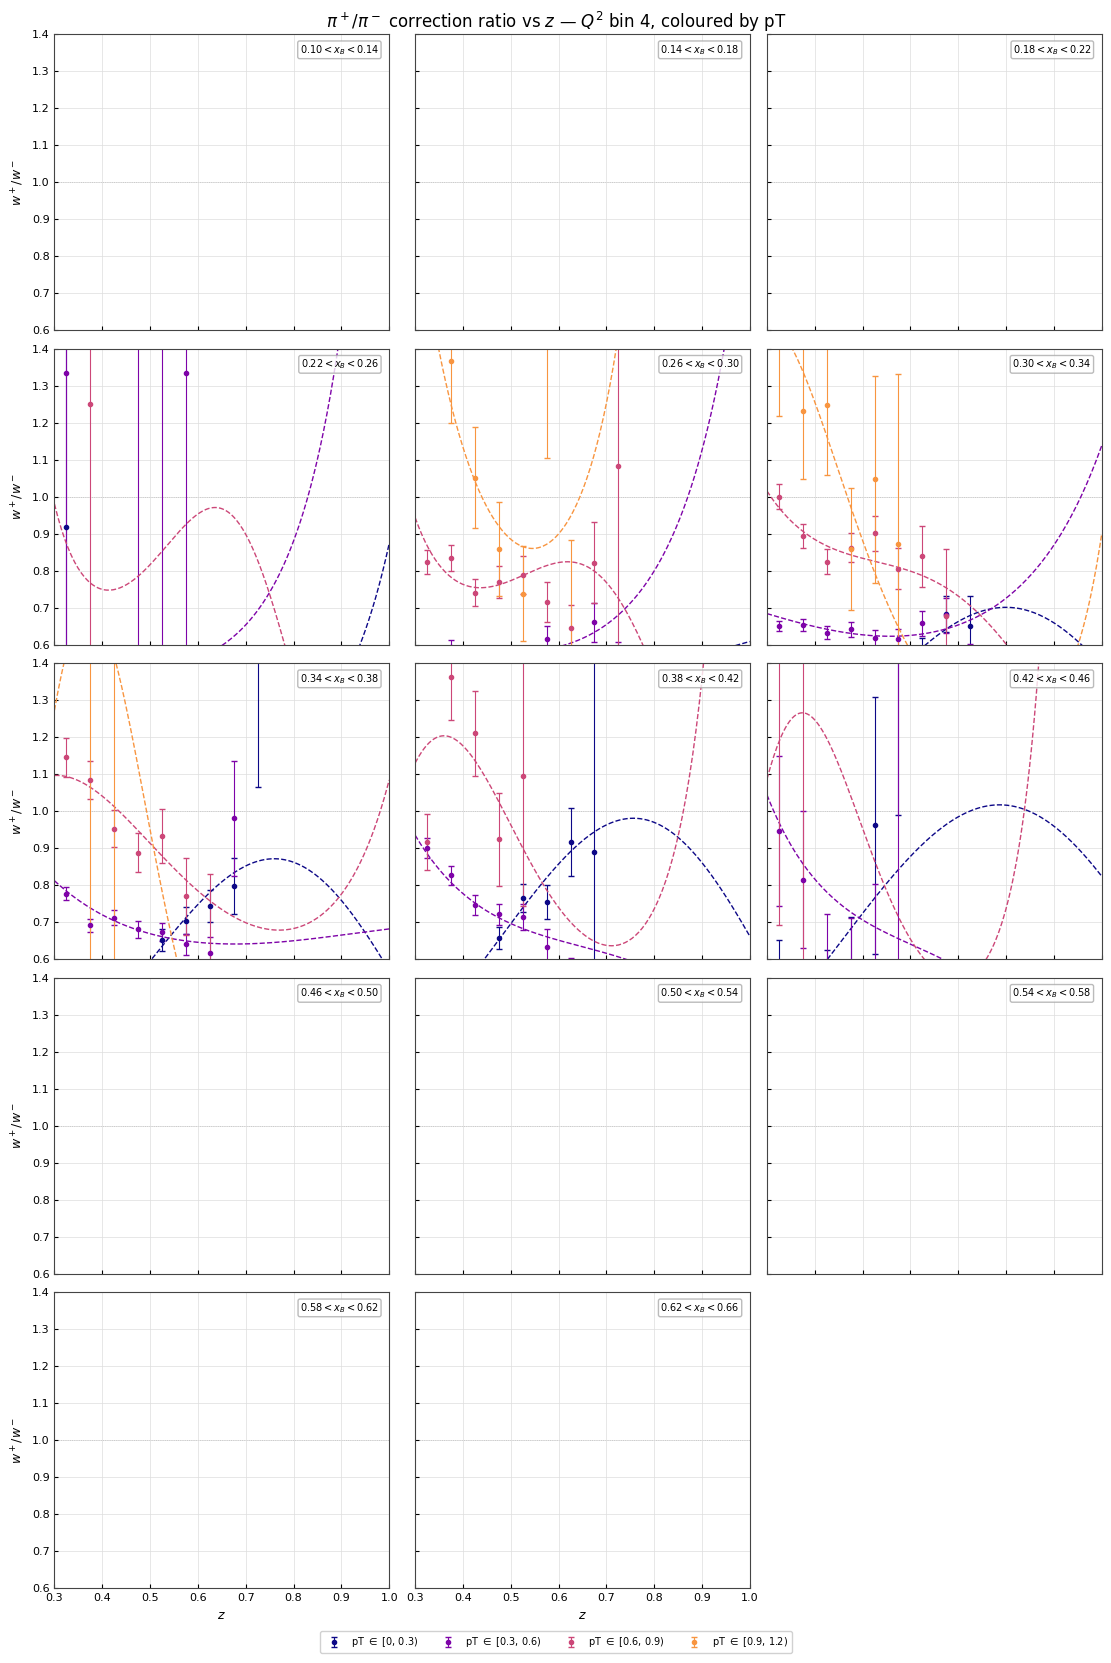

In [19]:
# ── π⁺ / π⁻ ratio vs z  (panels = xB bins, colours = var bins, fixed Q² bin) ─
def plot_4d_ratio_vs_z(vals_p, errs_p, vals_m, errs_m,
                       preds_p, preds_m, y_lim=(0.6, 1.4)):
    ncols = 3
    nrows = math.ceil(n_xB4 / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows),
                             constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(rf'$\pi^+/\pi^-$ correction ratio vs $z$ — '
                 rf'$Q^2$ bin {FIXED_Q2_BIN+1}, coloured by {vname}',
                 fontsize=12, y=1.01)
    axs_flat = axs.ravel()

    for ix in range(n_xB4):
        ax = axs_flat[ix]
        ax.text(0.97, 0.97,
                rf'${xB_edges4[ix]:.2f}<x_B<{xB_edges4[ix+1]:.2f}$',
                transform=ax.transAxes, ha='right', va='top', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.8))

        for pt in range(n4d):
            vp = vals_p[pt][ix, FIXED_Q2_BIN, :]
            ep = errs_p[pt][ix, FIXED_Q2_BIN, :]
            vm = vals_m[pt][ix, FIXED_Q2_BIN, :]
            em = errs_m[pt][ix, FIXED_Q2_BIN, :]
            mask = (np.isfinite(vp) & np.isfinite(vm) &
                    np.isfinite(ep) & np.isfinite(em) &
                    (vm > 0) & (ep > 0) & (em > 0))
            if not mask.any():
                continue

            ratio = np.where(mask, vp / vm, np.nan)
            err   = np.where(mask,
                             ratio * np.sqrt((ep / vp)**2 + (em / vm)**2),
                             np.nan)

            col = colors4[pt]
            lbl = rf'{vname} $\in$ [{vmin4+pt*var_step4:.3g}, {vmin4+(pt+1)*var_step4:.3g})'
            ax.errorbar(z_centers4[mask], ratio[mask], err[mask],
                        fmt='o', color=col, markersize=3, capsize=2, lw=0.8, label=lbl)

            xb_c = xB_centers4[ix];  q2_c = Q2_centers4[FIXED_Q2_BIN]
            fit_ratio = (preds_p[pt](z_fine4, np.full_like(z_fine4, xb_c), np.full_like(z_fine4, q2_c)) /
                         preds_m[pt](z_fine4, np.full_like(z_fine4, xb_c), np.full_like(z_fine4, q2_c)))
            ax.plot(z_fine4, fit_ratio, color=col, lw=1, ls='--')

        ax.axhline(1.0, color='gray', lw=0.6, ls=':', zorder=1)
        ax.set_xlim(z_edges4[0], z_edges4[-1])
        ax.set_ylim(y_lim)
        ax.tick_params(labelsize=8)
        col_idx = ix % ncols;  row_idx = ix // ncols
        if col_idx == 0: ax.set_ylabel(r'$w^+/w^-$', fontsize=9)
        if row_idx == nrows - 1: ax.set_xlabel(r'$z$', fontsize=9)

    for ax in axs_flat[n_xB4:]:
        ax.set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in axs_flat[:n_xB4]:
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    if all_h:
        fig.legend(all_h, all_l, loc='lower center',
                   bbox_to_anchor=(0.5, -0.02), ncol=min(n4d, 4),
                   fontsize=7, frameon=True)
    return fig

plot_4d_ratio_vs_z(vals4_P, errs4_P, vals4_M, errs4_M, preds4_P, preds4_M)
plt.show()